In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.optimize import minimize
from scipy.signal import correlate
import time
from matplotlib.legend_handler import HandlerTuple
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

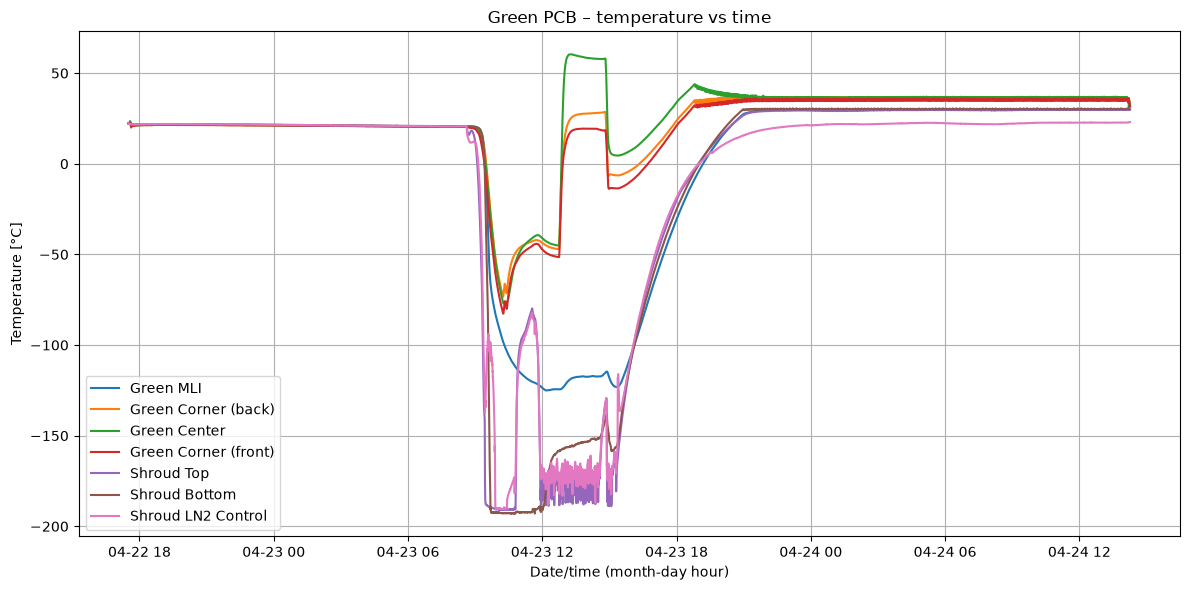

,Unnamed: 0,Unnamed: 1,Time,Unnamed: 3,Green MLI,Green Corner (back),Green Center,Green Corner (front),White MLI,White Corner (back),White Center,White Corner (front),Shroud Top,Shroud Bottom,Shroud LN2 Control
0,2026-04-22,17:31:00,2026-04-22 17:31:00,53,22.371314,22.373626,22.261025,22.249695,22.493151,22.427032,22.418478,22.411773,22.188541,22.128868,22.053563
1,2026-04-22,17:31:15,2026-04-22 17:31:15,68,22.336848,22.375922,22.254303,22.256384,22.453372,22.449904,22.408290,22.400429,22.172978,22.136037,21.983054
2,2026-04-22,17:31:30,2026-04-22 17:31:30,83,22.337168,22.357052,22.227107,22.219476,22.469181,22.427799,22.404910,22.393351,22.177920,22.140980,22.050992
3,2026-04-22,17:31:45,2026-04-22 17:31:45,98,22.324898,22.339233,22.221542,22.212524,22.455526,22.406976,22.398653,22.369521,22.167548,22.122557,22.009359
4,2026-04-22,17:32:00,2026-04-22 17:32:00,113,22.315494,22.337922,22.221849,22.208206,22.441268,22.388787,22.389943,22.370291,22.169342,22.133823,22.007837


In [2]:
# tweak these to point at the right sheet
file = "PCB_Rad_Summary.xlsx"
sheet = "Green&White 1"

# pull the data into a DataFrame
df = pd.read_excel(file, sheet_name=sheet)

# the channels we actually care about
time_col = "Time"
cols = [
    "Green MLI",
    "Green Corner (back)",
    "Green Center",
    "Green Corner (front)",
    "Shroud Top",
    "Shroud Bottom",
    "Shroud LN2 Control"
]

# make sure 'Time' is a real datetime, not a string
df[time_col] = pd.to_datetime(df[time_col])

# x-axis values
time_array = df[time_col].values

# {column: values} so the loop below stays readable
data_dict = {col: df[col].values for col in cols}

# one line per channel
plt.figure(figsize=(12, 6))
for col in cols:
    plt.plot(time_array, data_dict[col], label=col)

plt.xlabel("Date/time (month-day hour)")
plt.ylabel("Temperature [°C]")
plt.title("Green PCB – temperature vs time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# quick sanity check on what we loaded
df.head(5)

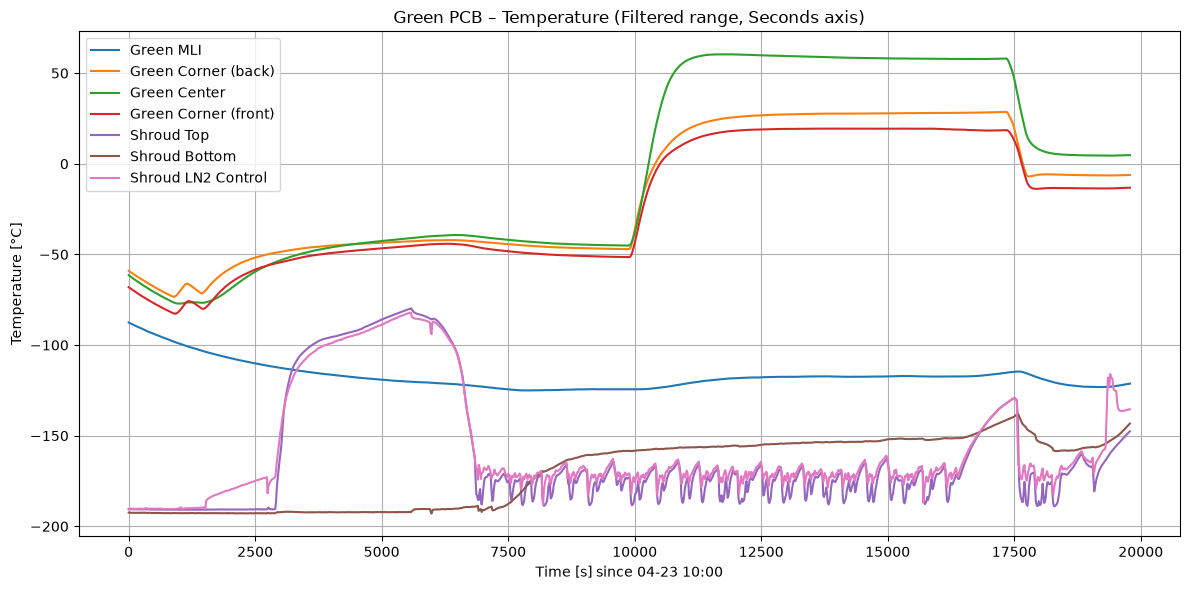

In [3]:
# zoom in on a specific time window
t_min = pd.to_datetime("2026-04-23 10:00")
t_max = pd.to_datetime("2026-04-23 15:30")

# keep only the rows inside that window
df_filt = df[(df[time_col] >= t_min) & (df[time_col] <= t_max)]

# shift the time axis so t = 0 is the start of the window
time_sec = (df_filt[time_col] - t_min).dt.total_seconds()

# same plot, but x is now in seconds
plt.figure(figsize=(12, 6))
for col in cols:
    plt.plot(time_sec, df_filt[col], label=col)

plt.xlabel("Time [s] since 04-23 10:00")
plt.ylabel("Temperature [°C]")
plt.title("Green PCB – Temperature (Filtered range, Seconds axis)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

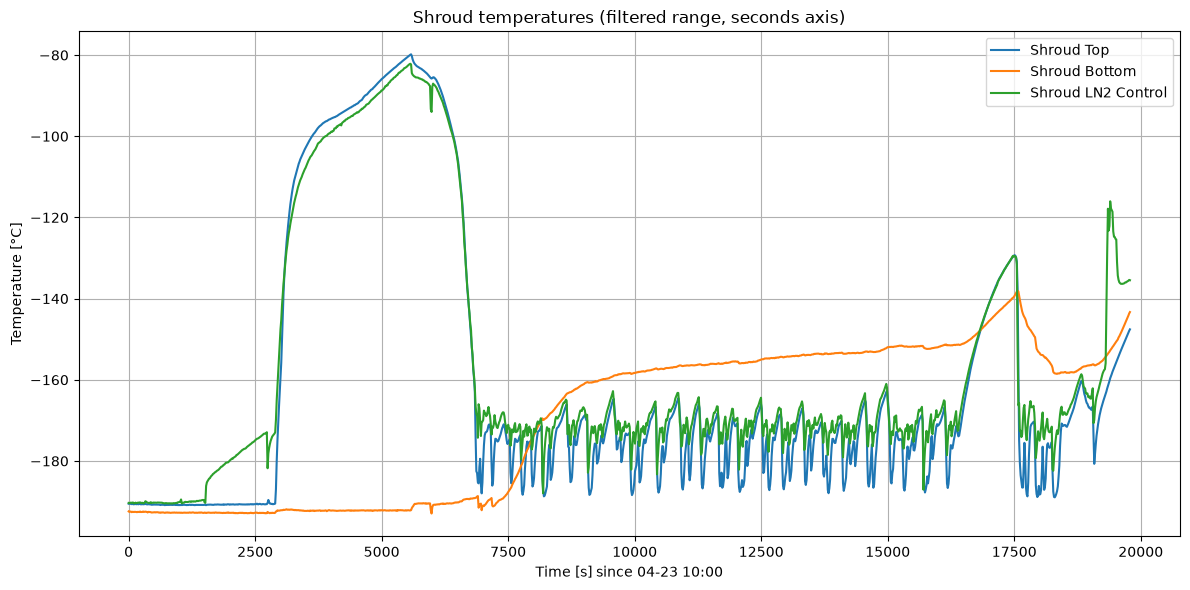

In [4]:
# only the shroud channels
shroud_cols = [col for col in cols if "Shroud" in col]

# same idea, just a smaller subset
plt.figure(figsize=(12, 6))
for col in shroud_cols:
    plt.plot(time_sec, df_filt[col], label=col)

plt.xlabel("Time [s] since 04-23 10:00")
plt.ylabel("Temperature [°C]")
plt.title("Shroud temperatures (filtered range, seconds axis)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

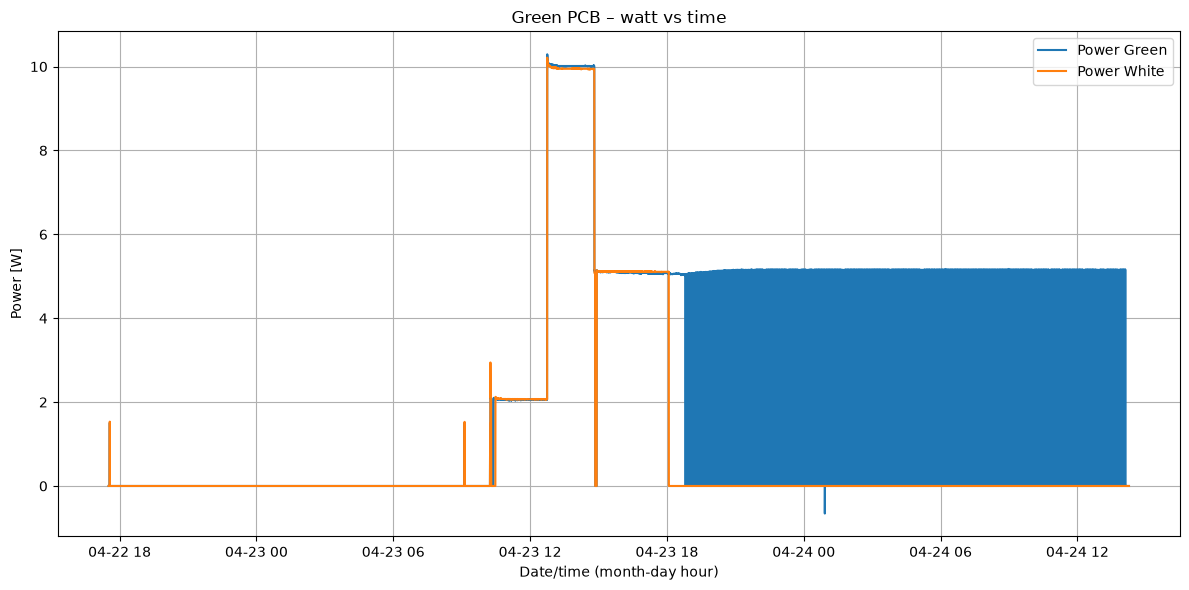

,Time,Power Green,Power White
0,2026-04-22 17:31:05,-0.000024,-0.000034
1,2026-04-22 17:31:20,-0.000025,-0.000034
2,2026-04-22 17:31:35,-0.000025,-0.000034
3,2026-04-22 17:31:50,-0.000024,-0.000034
4,2026-04-22 17:32:05,-0.000025,-0.000034


In [5]:
# power data lives in a different file
file_pwr = "Power_Green_White.xlsx"
sheet_pwr = "Sheet1"

# load it into its own DataFrame
df_pwr = pd.read_excel(file_pwr, sheet_name=sheet_pwr)

# the two power channels we want
time_col_pwr = "Time"
cols_pwr = ["Power Green", "Power White"]

# dates come in as dd/mm/yyyy, so dayfirst=True
df_pwr[time_col_pwr] = pd.to_datetime(df_pwr[time_col_pwr], dayfirst=True)

# x-axis values
time_array_pwr = df_pwr[time_col_pwr].values

# {column: values} so the loop stays clean
data_dict_pwr = {col: df_pwr[col].values for col in cols_pwr}

# one line per channel
plt.figure(figsize=(12, 6))
for col in cols_pwr:
    plt.plot(time_array_pwr, data_dict_pwr[col], label=col)

plt.xlabel("Date/time (month-day hour)")
plt.ylabel("Power [W]")
plt.title("Green PCB – watt vs time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# quick sanity check on what we loaded
df_pwr.head(5)

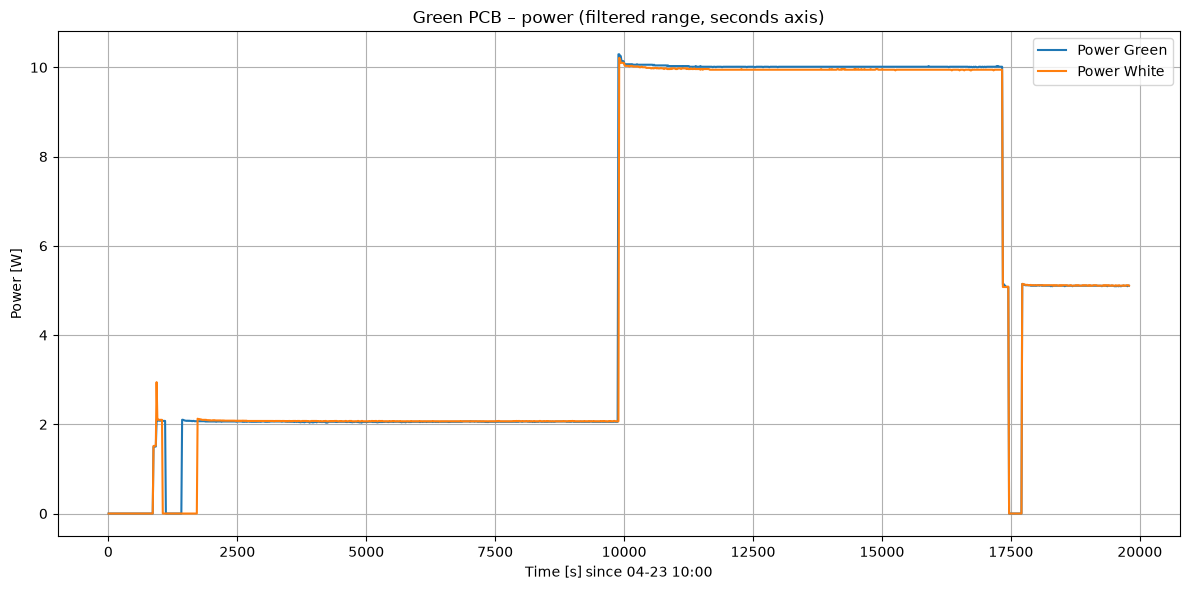

In [6]:
# same time window as for the temperatures
t_min = pd.to_datetime("2026-04-23 10:00")
t_max = pd.to_datetime("2026-04-23 15:30")

# keep only the rows inside that window
df_filt_pwr = df_pwr[(df_pwr[time_col_pwr] >= t_min) & (df_pwr[time_col_pwr] <= t_max)]

# shift the axis so t = 0 is the start of the window
time_sec_pwr = (df_filt_pwr[time_col_pwr] - t_min).dt.total_seconds()

# same plot, but x is now in seconds
plt.figure(figsize=(12, 6))
for col in cols_pwr:
    plt.plot(time_sec_pwr, df_filt_pwr[col], label=col)

plt.xlabel("Time [s] since 04-23 10:00")
plt.ylabel("Power [W]")
plt.title("Green PCB – power (filtered range, seconds axis)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

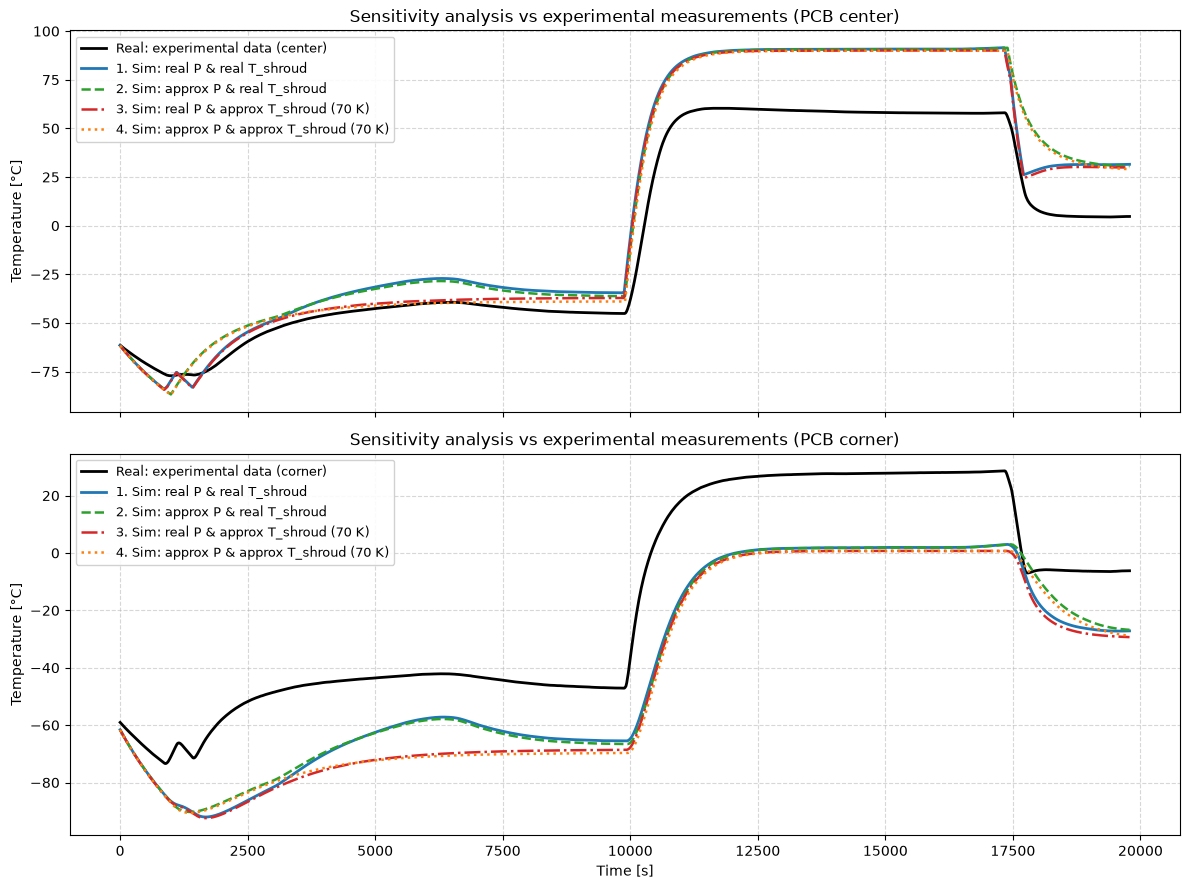

In [7]:
# ---------------------------------------------------------------------------
# get everything onto the same time grid before running the solver
# ---------------------------------------------------------------------------

# both datasets shifted to t = 0
time_pwr_sec = (df_filt_pwr[time_col_pwr] - t_min).dt.total_seconds().values
time_rad_sec = (df_filt[time_col] - t_min).dt.total_seconds().values

# effective shroud temperature from the real top/bottom readings (Kelvin)
T_top_K = df_filt["Shroud Top"].values + 273.15
T_bot_K = df_filt["Shroud Bottom"].values + 273.15
T_shroud_eff_K = (0.5 * (T_top_K**4) + 0.5 * (T_bot_K**4))**(1/4)

# cheap approximation: constant shroud at 70 K
T_shroud_const_K = 70

# step power profile, rough but matches the experiment phases
def get_step_power(t):
    """Step power profile that follows the actual experiment phases."""
    if t < 1000:
        return 0
    elif t < 9900:
        return 2
    elif t < 17400:
        return 10
    elif t <= 19800:
        return 5
    return 0

# common time grid for the simulation
dt = 5
time_total = min(time_pwr_sec[-1], time_rad_sec[-1])
Nt = int(time_total / dt)
time_array = np.linspace(0, time_total, Nt)

# interpolate the inputs onto that grid
P_real = np.interp(time_array, time_pwr_sec, df_filt_pwr["Power Green"].values)
P_step = np.array([get_step_power(t) for t in time_array])

T_shroud_real = np.interp(time_array, time_rad_sec, T_shroud_eff_K)
T_shroud_const = np.ones(Nt) * T_shroud_const_K

# ---------------------------------------------------------------------------
# geometry, material props and mesh
# ---------------------------------------------------------------------------
L, W, e = 0.1, 0.1, 0.0016
rho, cp, k = 1900.0, 1000.0, 0.75
emissivity = 0.9
sigma = 5.67e-8

Nx, Ny = 20, 20
dx, dy = L / Nx, W / Ny

efficiency = 0.6
heater_side = 0.08
x = np.linspace(dx/2, L - dx/2, Nx)
y = np.linspace(dy/2, W - dy/2, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# only the nodes under the heater actually receive power
heater_mask = (np.abs(X - L/2) <= heater_side/2) & (np.abs(Y - W/2) <= heater_side/2)
num_heated_nodes = np.sum(heater_mask)

C_node = rho * (dx * dy * e) * cp
T_init_K = df_filt["Green Center"].iloc[0] + 273.15

# ---------------------------------------------------------------------------
# the solver itself + the 4 cases we want to compare
# ---------------------------------------------------------------------------

def run_thermal_simulation(P_input_array, T_shroud_array):
    """2D transient solver: conduction + radiation + heater input."""
    T = np.ones((Nx, Ny)) * T_init_K
    T_history = np.zeros((Nt, Nx, Ny))

    for i in range(Nt):
        P_eff = P_input_array[i] * efficiency
        T_env = T_shroud_array[i]

        # conduction term (5-point stencil)
        T_pad = np.pad(T, ((1, 1), (1, 1)), mode='edge')
        Q_cond_x = k * e * (dy/dx) * (T_pad[1:-1, :-2] + T_pad[1:-1, 2:] - 2*T)
        Q_cond_z = k * e * (dx/dy) * (T_pad[2:, 1:-1] + T_pad[:-2, 1:-1] - 2*T)
        Q_cond = Q_cond_x + Q_cond_z

        # radiative exchange with the shroud
        Q_rad = emissivity * sigma * (dx * dy) * (T**4 - T_env**4)

        # power dumped into the heater nodes, split evenly
        P_per_node = P_eff / num_heated_nodes if num_heated_nodes > 0 else 0
        Q_heat = heater_mask * P_per_node

        # explicit step
        T = T + ((Q_cond + Q_heat - Q_rad) / C_node) * dt
        T_history[i, :, :] = T - 273.15

    return T_history

# the 4 combinations: real vs approx for both power and shroud
sim_results = {
    "both_real": run_thermal_simulation(P_real, T_shroud_real),
    "cstP_realT": run_thermal_simulation(P_step, T_shroud_real),
    "realP_cstT": run_thermal_simulation(P_real, T_shroud_const),
    "both_cst": run_thermal_simulation(P_step, T_shroud_const)
}

# ---------------------------------------------------------------------------
# sensitivity analysis: compare the 4 cases against the actual measurements
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# center node
ax1.plot(time_rad_sec, df_filt["Green Center"], color="black", linewidth=2.0, label="Real: experimental data (center)")
ax1.plot(time_array, sim_results["both_real"][:, Nx//2, Ny//2], color="#1f77b4", linewidth=2.0, label="1. Sim: real P & real T_shroud")
ax1.plot(time_array, sim_results["cstP_realT"][:, Nx//2, Ny//2], color="#2ca02c", linestyle="--", linewidth=1.8, label="2. Sim: approx P & real T_shroud")
ax1.plot(time_array, sim_results["realP_cstT"][:, Nx//2, Ny//2], color="#d62728", linestyle="-.", linewidth=1.8, label="3. Sim: real P & approx T_shroud (70 K)")
ax1.plot(time_array, sim_results["both_cst"][:, Nx//2, Ny//2], color="#ff7f0e", linestyle=":", linewidth=1.8, label="4. Sim: approx P & approx T_shroud (70 K)")

ax1.set_ylabel("Temperature [°C]")
ax1.set_title("Sensitivity analysis vs experimental measurements (PCB center)")
ax1.legend(loc="upper left", frameon=True, framealpha=0.9, fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.5)

# corner node
ax2.plot(time_rad_sec, df_filt["Green Corner (back)"], color="black", linewidth=2.0, label="Real: experimental data (corner)")
ax2.plot(time_array, sim_results["both_real"][:, 0, 0], color="#1f77b4", linewidth=2.0, label="1. Sim: real P & real T_shroud")
ax2.plot(time_array, sim_results["cstP_realT"][:, 0, 0], color="#2ca02c", linestyle="--", linewidth=1.8, label="2. Sim: approx P & real T_shroud")
ax2.plot(time_array, sim_results["realP_cstT"][:, 0, 0], color="#d62728", linestyle="-.", linewidth=1.8, label="3. Sim: real P & approx T_shroud (70 K)")
ax2.plot(time_array, sim_results["both_cst"][:, 0, 0], color="#ff7f0e", linestyle=":", linewidth=1.8, label="4. Sim: approx P & approx T_shroud (70 K)")

ax2.set_ylabel("Temperature [°C]")
ax2.set_xlabel("Time [s]")
ax2.set_title("Sensitivity analysis vs experimental measurements (PCB corner)")
ax2.legend(loc="upper left", frameon=True, framealpha=0.9, fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

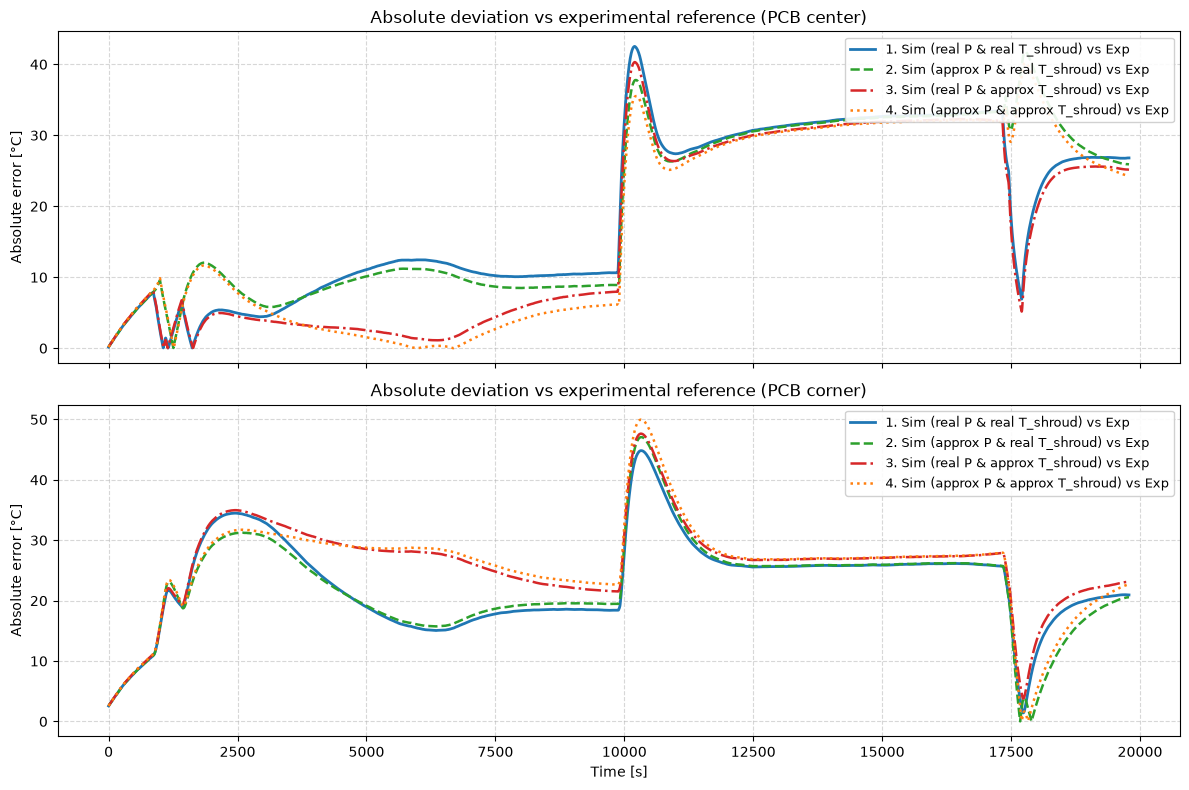

Maximum absolute deviations vs experimental data
Center - Sim 1 (real P and real shroud)     : 42.52 °C
Center - Sim 2 (approx P and real shroud)   : 41.76 °C
Center - Sim 3 (real P and approx shroud)   : 40.32 °C
Center - Sim 4 (approx P and approx shroud) : 40.25 °C
  
Corner - Sim 1 (real P and real shroud)     : 44.84 °C
Corner - Sim 2 (approx P and real shroud)   : 47.08 °C
Corner - Sim 3 (real P and approx shroud)   : 47.65 °C
Corner - Sim 4 (approx P and approx shroud) : 49.98 °C


In [8]:
# ---------------------------------------------------------------------------
# absolute error analysis
# ---------------------------------------------------------------------------

# bring the experimental readings onto the sim time grid
exp_center_C = np.interp(time_array, time_rad_sec, df_filt["Green Center"].values)
exp_corner_C = np.interp(time_array, time_rad_sec, df_filt["Green Corner (back)"].values)

# abs error of each case vs the real measurements
err_center_sim1 = np.abs(sim_results["both_real"][:, Nx//2, Ny//2] - exp_center_C)
err_center_sim2 = np.abs(sim_results["cstP_realT"][:, Nx//2, Ny//2] - exp_center_C)
err_center_sim3 = np.abs(sim_results["realP_cstT"][:, Nx//2, Ny//2] - exp_center_C)
err_center_sim4 = np.abs(sim_results["both_cst"][:, Nx//2, Ny//2] - exp_center_C)

err_corner_sim1 = np.abs(sim_results["both_real"][:, 0, 0] - exp_corner_C)
err_corner_sim2 = np.abs(sim_results["cstP_realT"][:, 0, 0] - exp_corner_C)
err_corner_sim3 = np.abs(sim_results["realP_cstT"][:, 0, 0] - exp_corner_C)
err_corner_sim4 = np.abs(sim_results["both_cst"][:, 0, 0] - exp_corner_C)

# plot the errors side by side
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# center node
ax1.plot(time_array, err_center_sim1, color="#1f77b4", linewidth=2.0, label="1. Sim (real P & real T_shroud) vs Exp")
ax1.plot(time_array, err_center_sim2, color="#2ca02c", linestyle="--", linewidth=1.8, label="2. Sim (approx P & real T_shroud) vs Exp")
ax1.plot(time_array, err_center_sim3, color="#d62728", linestyle="-.", linewidth=1.8, label="3. Sim (real P & approx T_shroud) vs Exp")
ax1.plot(time_array, err_center_sim4, color="#ff7f0e", linestyle=":", linewidth=1.8, label="4. Sim (approx P & approx T_shroud) vs Exp")

ax1.set_ylabel("Absolute error [°C]")
ax1.set_title("Absolute deviation vs experimental reference (PCB center)")
ax1.legend(loc="upper right", frameon=True, framealpha=0.9, fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.5)

# corner node
ax2.plot(time_array, err_corner_sim1, color="#1f77b4", linewidth=2.0, label="1. Sim (real P & real T_shroud) vs Exp")
ax2.plot(time_array, err_corner_sim2, color="#2ca02c", linestyle="--", linewidth=1.8, label="2. Sim (approx P & real T_shroud) vs Exp")
ax2.plot(time_array, err_corner_sim3, color="#d62728", linestyle="-.", linewidth=1.8, label="3. Sim (real P & approx T_shroud) vs Exp")
ax2.plot(time_array, err_corner_sim4, color="#ff7f0e", linestyle=":", linewidth=1.8, label="4. Sim (approx P & approx T_shroud) vs Exp")

ax2.set_ylabel("Absolute error [°C]")
ax2.set_xlabel("Time [s]")
ax2.set_title("Absolute deviation vs experimental reference (PCB corner)")
ax2.legend(loc="upper right", frameon=True, framealpha=0.9, fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# quick summary of the worst-case deviation for each case
# ---------------------------------------------------------------------------
print("Maximum absolute deviations vs experimental data")
print(f"Center - Sim 1 (real P and real shroud)     : {np.max(err_center_sim1):.2f} °C")
print(f"Center - Sim 2 (approx P and real shroud)   : {np.max(err_center_sim2):.2f} °C")
print(f"Center - Sim 3 (real P and approx shroud)   : {np.max(err_center_sim3):.2f} °C")
print(f"Center - Sim 4 (approx P and approx shroud) : {np.max(err_center_sim4):.2f} °C")
print("  ")
print(f"Corner - Sim 1 (real P and real shroud)     : {np.max(err_corner_sim1):.2f} °C")
print(f"Corner - Sim 2 (approx P and real shroud)   : {np.max(err_corner_sim2):.2f} °C")
print(f"Corner - Sim 3 (real P and approx shroud)   : {np.max(err_corner_sim3):.2f} °C")
print(f"Corner - Sim 4 (approx P and approx shroud) : {np.max(err_corner_sim4):.2f} °C")

Center metrics table
                        RMSE [°C]   MAE [°C]  Max error [°C]  R² score  \
1. real P & real T      22.309002  19.054421       42.520538  0.993292   
2. approx P & real T    23.074399  19.843954       41.756350  0.992222   
3. real P & approx T    20.929400  16.397576       40.315159  0.993014   
4. approx P & approx T  21.809036  17.178245       40.248032  0.990308   

                        NRMSE [%]  
1. real P & real T      16.222966  
2. approx P & real T    16.779558  
3. real P & approx T    15.219728  
4. approx P & approx T  15.859394  

Corner metrics table
                        RMSE [°C]   MAE [°C]  Max error [°C]  R² score  \
1. real P & real T      24.073926  22.836105       44.842692  0.955223   
2. approx P & real T    23.853299  22.478742       47.080669  0.948739   
3. real P & approx T    27.100361  26.116411       47.653270  0.958677   
4. approx P & approx T  26.940528  25.732383       49.976145  0.949322   

                        NRMSE [%]  

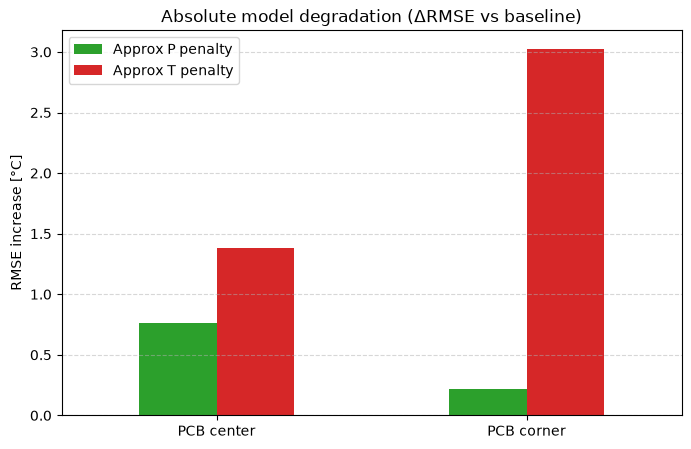

In [9]:
# ---------------------------------------------------------------------------
# squeeze a few extra metrics out of each case to see which approximation
# hurts the most
# ---------------------------------------------------------------------------

# RMSE, MAE, max error, Rsquare and a normalized RMSE, all in one go
def get_metrics_dict(sim_arr, exp_arr):
    err = np.abs(sim_arr - exp_arr)
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(err)
    max_err = np.max(err)

    r2 = (np.corrcoef(sim_arr, exp_arr)[0, 1])**2

    # NRMSE as % of the experimental range
    ptp = np.ptp(exp_arr)
    nrmse = (rmse / ptp * 100) if ptp != 0 else 0.0

    return {
        "RMSE [°C]": rmse,
        "MAE [°C]": mae,
        "Max error [°C]": max_err,
        "R² score": r2,
        "NRMSE [%]": nrmse
    }

# one row per simulation case, center node
df_center = pd.DataFrame([
    get_metrics_dict(sim_results["both_real"][:, Nx//2, Ny//2], exp_center_C),
    get_metrics_dict(sim_results["cstP_realT"][:, Nx//2, Ny//2], exp_center_C),
    get_metrics_dict(sim_results["realP_cstT"][:, Nx//2, Ny//2], exp_center_C),
    get_metrics_dict(sim_results["both_cst"][:, Nx//2, Ny//2], exp_center_C)
], index=[
    "1. real P & real T",
    "2. approx P & real T",
    "3. real P & approx T",
    "4. approx P & approx T"
])

# same thing for the corner node
df_corner = pd.DataFrame([
    get_metrics_dict(sim_results["both_real"][:, 0, 0], exp_corner_C),
    get_metrics_dict(sim_results["cstP_realT"][:, 0, 0], exp_corner_C),
    get_metrics_dict(sim_results["realP_cstT"][:, 0, 0], exp_corner_C),
    get_metrics_dict(sim_results["both_cst"][:, 0, 0], exp_corner_C)
], index=[
    "1. real P & real T",
    "2. approx P & real T",
    "3. real P & approx T",
    "4. approx P & approx T"
])

print("Center metrics table")
print(df_center)

print("\nCorner metrics table")
print(df_corner)

# how much RMSE goes up when we drop either P or T_shroud to its approximation
delta_P_center = abs(df_center.loc["2. approx P & real T", "RMSE [°C]"] - df_center.loc["1. real P & real T", "RMSE [°C]"])
delta_T_center = abs(df_center.loc["3. real P & approx T", "RMSE [°C]"] - df_center.loc["1. real P & real T", "RMSE [°C]"])

df_impact = pd.DataFrame({
    "ΔRMSE penalty [°C]": [delta_P_center, delta_T_center],
    "Relative impact factor": [1.0, delta_T_center / max(delta_P_center, 1e-5)]
}, index=["Approximating power (P)", "Approximating shroud temp (T)"])

print("\nRelative impact table")
print(df_impact)

# ---------------------------------------------------------------------------
# bar chart of the RMSE penalty for each approximation, center vs corner
# ---------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

df_degradation = pd.DataFrame({
    'Approx P penalty': [
        abs(df_center.loc["2. approx P & real T", "RMSE [°C]"] - df_center.loc["1. real P & real T", "RMSE [°C]"]),
        abs(df_corner.loc["2. approx P & real T", "RMSE [°C]"] - df_corner.loc["1. real P & real T", "RMSE [°C]"])
    ],
    'Approx T penalty': [
        abs(df_center.loc["3. real P & approx T", "RMSE [°C]"] - df_center.loc["1. real P & real T", "RMSE [°C]"]),
        abs(df_corner.loc["3. real P & approx T", "RMSE [°C]"] - df_corner.loc["1. real P & real T", "RMSE [°C]"])
    ]
}, index=['PCB center', 'PCB corner'])

df_degradation.plot(kind='bar', ax=ax1, color=['#2ca02c', '#d62728'], rot=0)
ax1.set_ylabel('RMSE increase [°C]')
ax1.set_title('Absolute model degradation (ΔRMSE vs baseline)')
ax1.grid(True, linestyle="--", alpha=0.5, axis='y')

plt.show()


Model performance metrics (step P and real T_shroud)
                 RMSE [°C]   MAE [°C]  Max error [°C]  Rsquare score
PCB center node  23.074399  19.843954       41.756350       0.992222
PCB corner node  23.853299  22.478742       47.080669       0.948739


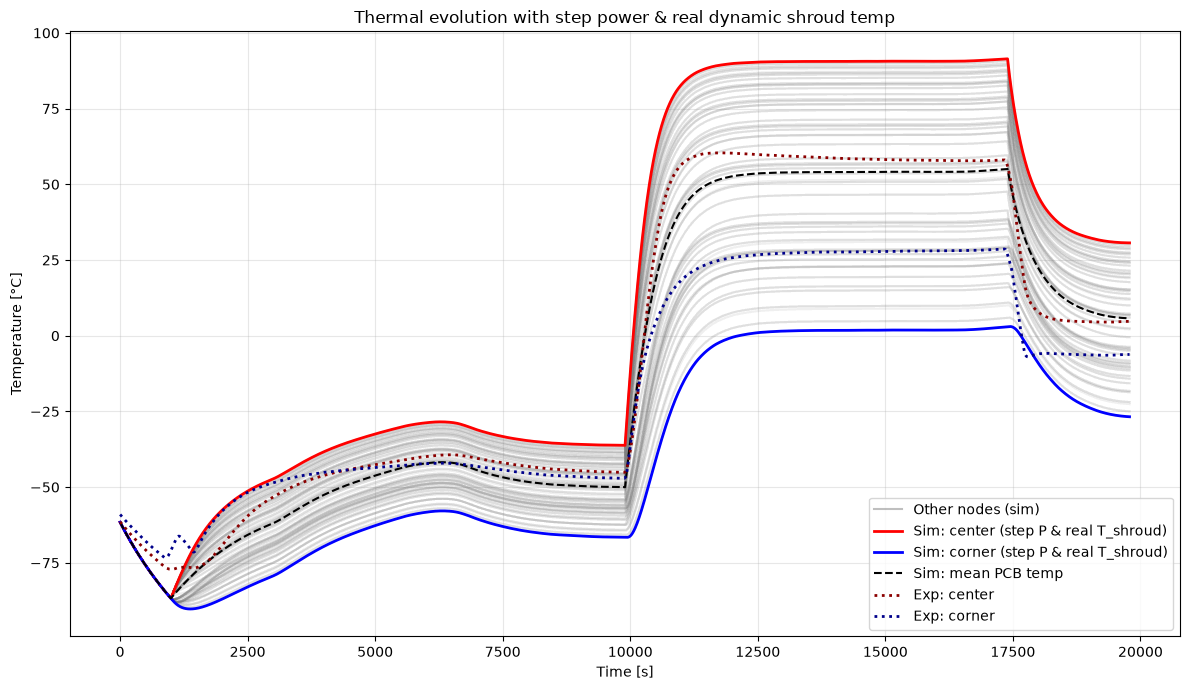

In [10]:
# ---------------------------------------------------------------------------
# run a single case inline: step power + real shroud, store the full field
# ---------------------------------------------------------------------------

T = np.ones((Nx, Ny)) * T_init_K
T_all_history = np.zeros((Nt, Nx, Ny))

for i in range(Nt):
    P_eff = P_step[i] * efficiency
    T_env = T_shroud_real[i]  # real dynamic shroud temperature

    # conduction (Neumann BCs via edge padding)
    T_pad = np.pad(T, ((1, 1), (1, 1)), mode='edge')
    Q_cond_x = k * e * (dy/dx) * (T_pad[1:-1, :-2] + T_pad[1:-1, 2:] - 2*T)
    Q_cond_z = k * e * (dx/dy) * (T_pad[2:, 1:-1] + T_pad[:-2, 1:-1] - 2*T)
    Q_cond = Q_cond_x + Q_cond_z

    # radiation + heater input
    Q_rad = emissivity * sigma * (dx * dy) * (T**4 - T_env**4)
    P_per_node = P_eff / num_heated_nodes if num_heated_nodes > 0 else 0.0
    Q_heat = heater_mask * P_per_node

    # explicit step, store in °C
    T = T + ((Q_cond + Q_heat - Q_rad) / C_node) * dt
    T_all_history[i, :, :] = T - 273.15

# ---------------------------------------------------------------------------
# metrics for this single case
# ---------------------------------------------------------------------------

sim_center_C = T_all_history[:, Nx//2, Ny//2]
sim_corner_C = T_all_history[:, 0, 0]

def compute_metrics(sim_arr, exp_arr):
    err = np.abs(sim_arr - exp_arr)
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(err)
    max_err = np.max(err)
    r2 = (np.corrcoef(sim_arr, exp_arr)[0, 1])**2
    return {"RMSE [°C]": rmse, "MAE [°C]": mae, "Max error [°C]": max_err, "Rsquare score": r2}

df_metrics = pd.DataFrame([
    compute_metrics(sim_center_C, exp_center_C),
    compute_metrics(sim_corner_C, exp_corner_C)
], index=["PCB center node", "PCB corner node"])

print("\nModel performance metrics (step P and real T_shroud)")
print(df_metrics)

# ---------------------------------------------------------------------------
# plot: full mesh trajectories + center/corner/mean vs experimental
# ---------------------------------------------------------------------------

temp_center = sim_center_C
temp_corner = sim_corner_C
temp_mean = np.mean(T_all_history, axis=(1, 2))

plt.figure(figsize=(12, 7))

# every node in the background, very faint
T_flat_history = T_all_history.reshape(Nt, Nx * Ny)
plt.plot(time_array, T_flat_history, color='gray', alpha=0.03)
plt.plot([], [], color='gray', alpha=0.5, label='Other nodes (sim)')

# sim curves
plt.plot(time_array, temp_center, color='red', linewidth=2, label='Sim: center (step P & real T_shroud)')
plt.plot(time_array, temp_corner, color='blue', linewidth=2, label='Sim: corner (step P & real T_shroud)')
plt.plot(time_array, temp_mean, color='black', linewidth=1.5, linestyle='--', label='Sim: mean PCB temp')

# experimental reference
plt.plot(time_rad_sec, df_filt["Green Center"], color='darkred', linestyle=':', linewidth=2, label='Exp: center')
plt.plot(time_rad_sec, df_filt["Green Corner (back)"], color='darkblue', linestyle=':', linewidth=2, label='Exp: corner')

plt.title("Thermal evolution with step power & real dynamic shroud temp")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Running implicit solver (20x20 grid, dt = 5s, Nt = 3957 steps)...

Implicit model performance metrics (step P and real T_shroud)
                            RMSE [°C]   MAE [°C]  Max error [°C]  \
PCB center node (implicit)  23.063371  19.826483       42.053299   
PCB corner node (implicit)  23.860828  22.480521       46.995756   

                            Rsquare score  
PCB center node (implicit)       0.992179  
PCB corner node (implicit)       0.948538  


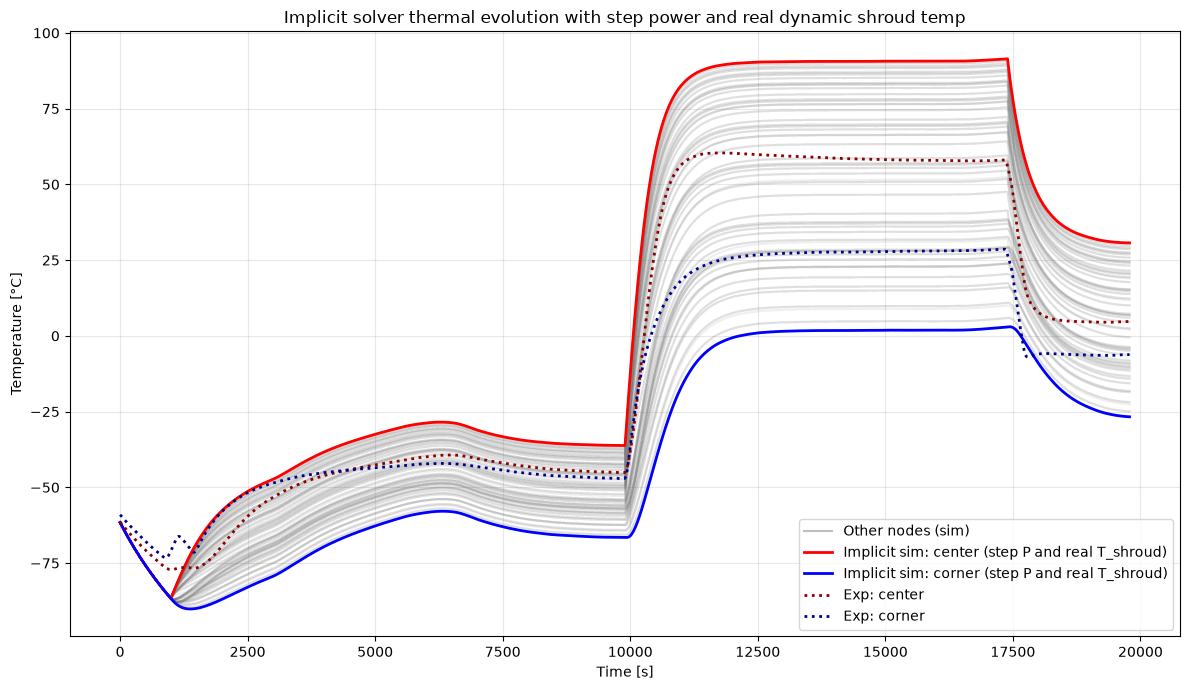

In [11]:
# ---------------------------------------------------------------------------
# implicit solver: same physics, but backward Euler + sparse linear solve
# needs a flattened mesh, so heater_mask gets flattened here
# ---------------------------------------------------------------------------

N_nodes = Nx * Ny
A_node = dx * dy

heater_mask = ((np.abs(X - L/2) <= heater_side/2) & (np.abs(Y - W/2) <= heater_side/2)).flatten()

Gx = k * e * (dy / dx)
Gy = k * e * (dx / dy)

def get_index(i, j):
    return i * Ny + j

T_vec = np.ones(N_nodes) * T_init_K
T_all_history = np.zeros((Nt, Nx, Ny))

print(f"Running implicit solver ({Nx}x{Ny} grid, dt = {dt}s, Nt = {Nt} steps)...")

for step in range(Nt):
    T_env = T_shroud_real[step]

    P_eff = P_step[step] * efficiency
    P_per_node = (P_eff / num_heated_nodes) if num_heated_nodes > 0 else 0.0
    Q_heat = heater_mask * P_per_node

    # linearize radiation around T^n
    h_rad_eq = 4.0 * emissivity * sigma * A_node * (T_vec**3)
    Q_rad_n = emissivity * sigma * A_node * (T_vec**4 - T_env**4)

    # assemble A x = B
    A = lil_matrix((N_nodes, N_nodes))
    B = np.zeros(N_nodes)

    for i in range(Nx):
        for j in range(Ny):
            p = get_index(i, j)

            diag_val = (C_node / dt) + h_rad_eq[p]

            if i > 0:
                A[p, get_index(i-1, j)] = -Gx
                diag_val += Gx
            if i < Nx - 1:
                A[p, get_index(i+1, j)] = -Gx
                diag_val += Gx
            if j > 0:
                A[p, get_index(i, j-1)] = -Gy
                diag_val += Gy
            if j < Ny - 1:
                A[p, get_index(i, j+1)] = -Gy
                diag_val += Gy

            A[p, p] = diag_val
            B[p] = (C_node / dt) * T_vec[p] + Q_heat[p] - Q_rad_n[p] + h_rad_eq[p] * T_vec[p]

    T_vec = spsolve(A.tocsr(), B)
    T_all_history[step, :, :] = T_vec.reshape((Nx, Ny)) - 273.15

# ---------------------------------------------------------------------------
# metrics
# ---------------------------------------------------------------------------

sim_center_C = T_all_history[:, Nx//2, Ny//2]
sim_corner_C = T_all_history[:, 0, 0]

df_metrics = pd.DataFrame([
    compute_metrics(sim_center_C, exp_center_C),
    compute_metrics(sim_corner_C, exp_corner_C)
], index=["PCB center node (implicit)", "PCB corner node (implicit)"])

print("\nImplicit model performance metrics (step P and real T_shroud)")
print(df_metrics)

# ---------------------------------------------------------------------------
# plot: mesh trajectories + center/corner vs experimental
# ---------------------------------------------------------------------------

temp_center = sim_center_C
temp_corner = sim_corner_C

plt.figure(figsize=(12, 7))

T_flat_history = T_all_history.reshape(Nt, Nx * Ny)
plt.plot(time_array, T_flat_history, color='gray', alpha=0.03)
plt.plot([], [], color='gray', alpha=0.5, label='Other nodes (sim)')

plt.plot(time_array, temp_center, color='red', linewidth=2, label='Implicit sim: center (step P and real T_shroud)')
plt.plot(time_array, temp_corner, color='blue', linewidth=2, label='Implicit sim: corner (step P and real T_shroud)')

plt.plot(time_rad_sec, df_filt["Green Center"], color='darkred', linestyle=':', linewidth=2, label='Exp: center')
plt.plot(time_rad_sec, df_filt["Green Corner (back)"], color='darkblue', linestyle=':', linewidth=2, label='Exp: corner')

plt.title("Implicit solver thermal evolution with step power and real dynamic shroud temp")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Running spatial convergence study (dt = 200.0s, 98 steps)...
 -> mesh  10x10  done in 0.11s
 -> mesh  25x25  done in 0.65s
 -> mesh  50x50  done in 3.13s
 -> mesh 100x100 done in 13.38s
 -> mesh 200x200 done in 56.72s

Mesh spatial convergence metrics
           Center RMSE [°C]  Center MAE [°C]  Corner RMSE [°C]  \
Mesh size                                                        
10x10             23.483595        20.200043         23.554712   
25x25             18.488641        15.529604         18.589381   
50x50             23.874440        20.548733         23.280841   
100x100           23.886856        20.559799         23.269640   
200x200           23.889961        20.562567         23.266800   

           Corner MAE [°C]  CPU time [s]  
Mesh size                                 
10x10            22.403144      0.105191  
25x25            17.696607      0.648535  
50x50            22.143241      3.134761  
100x100          22.132678     13.375154  
200x200          22.130001 

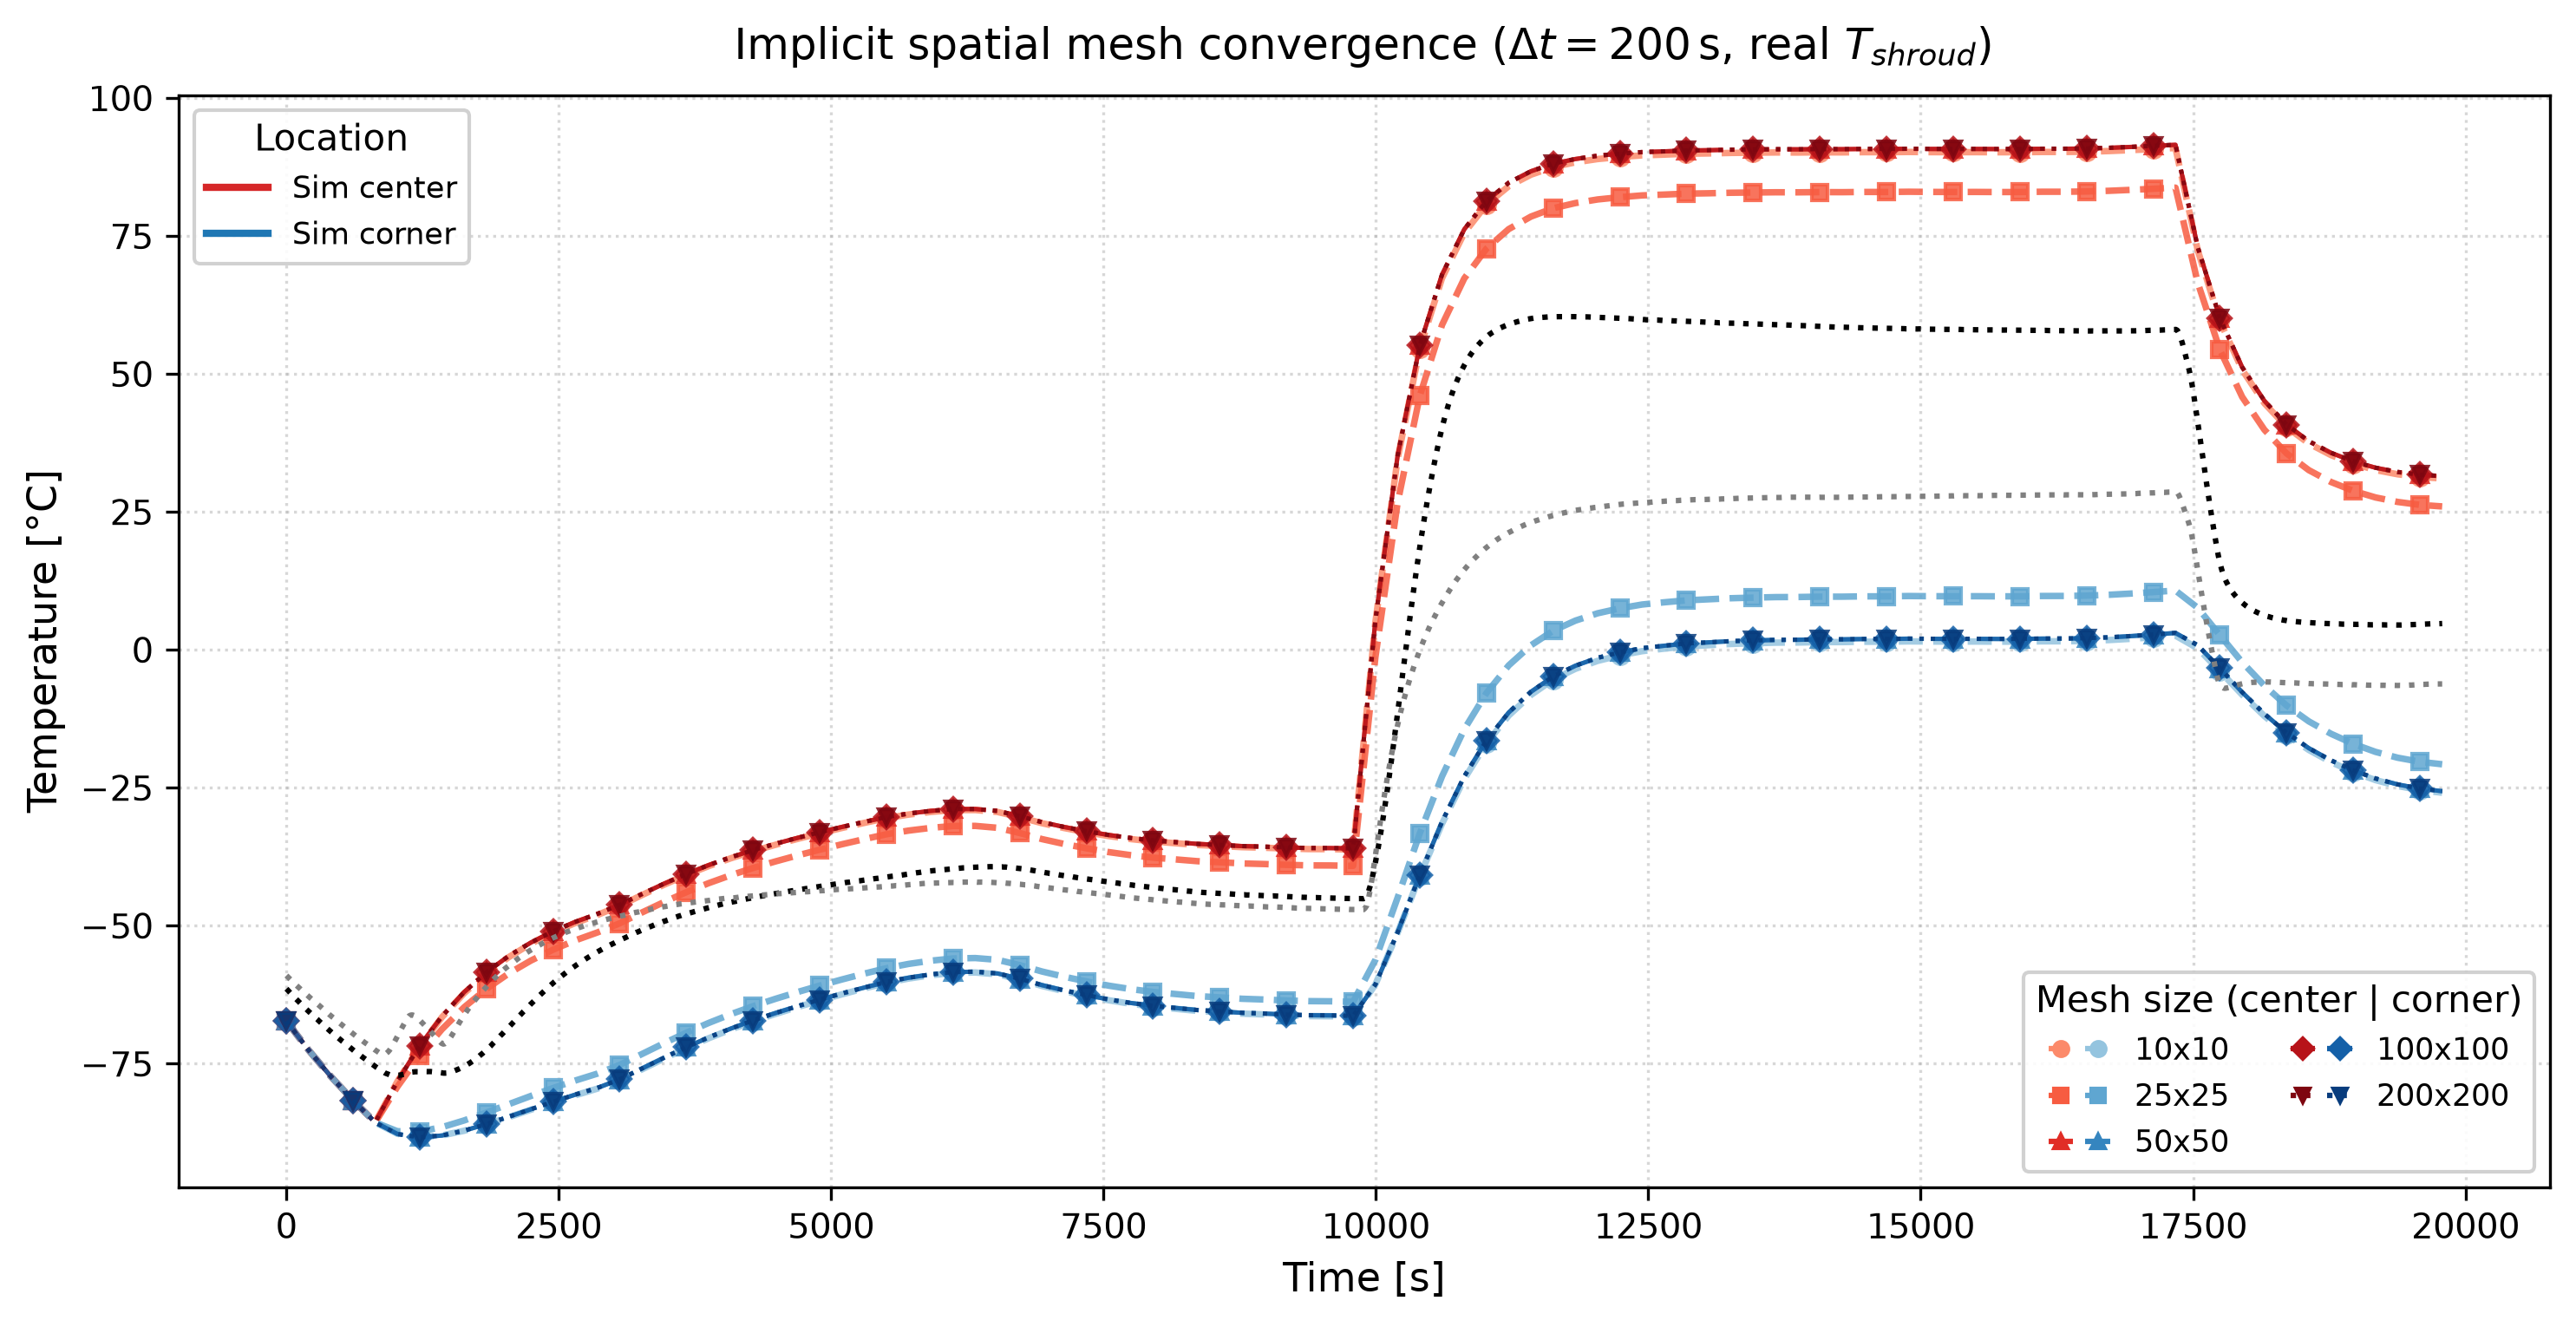

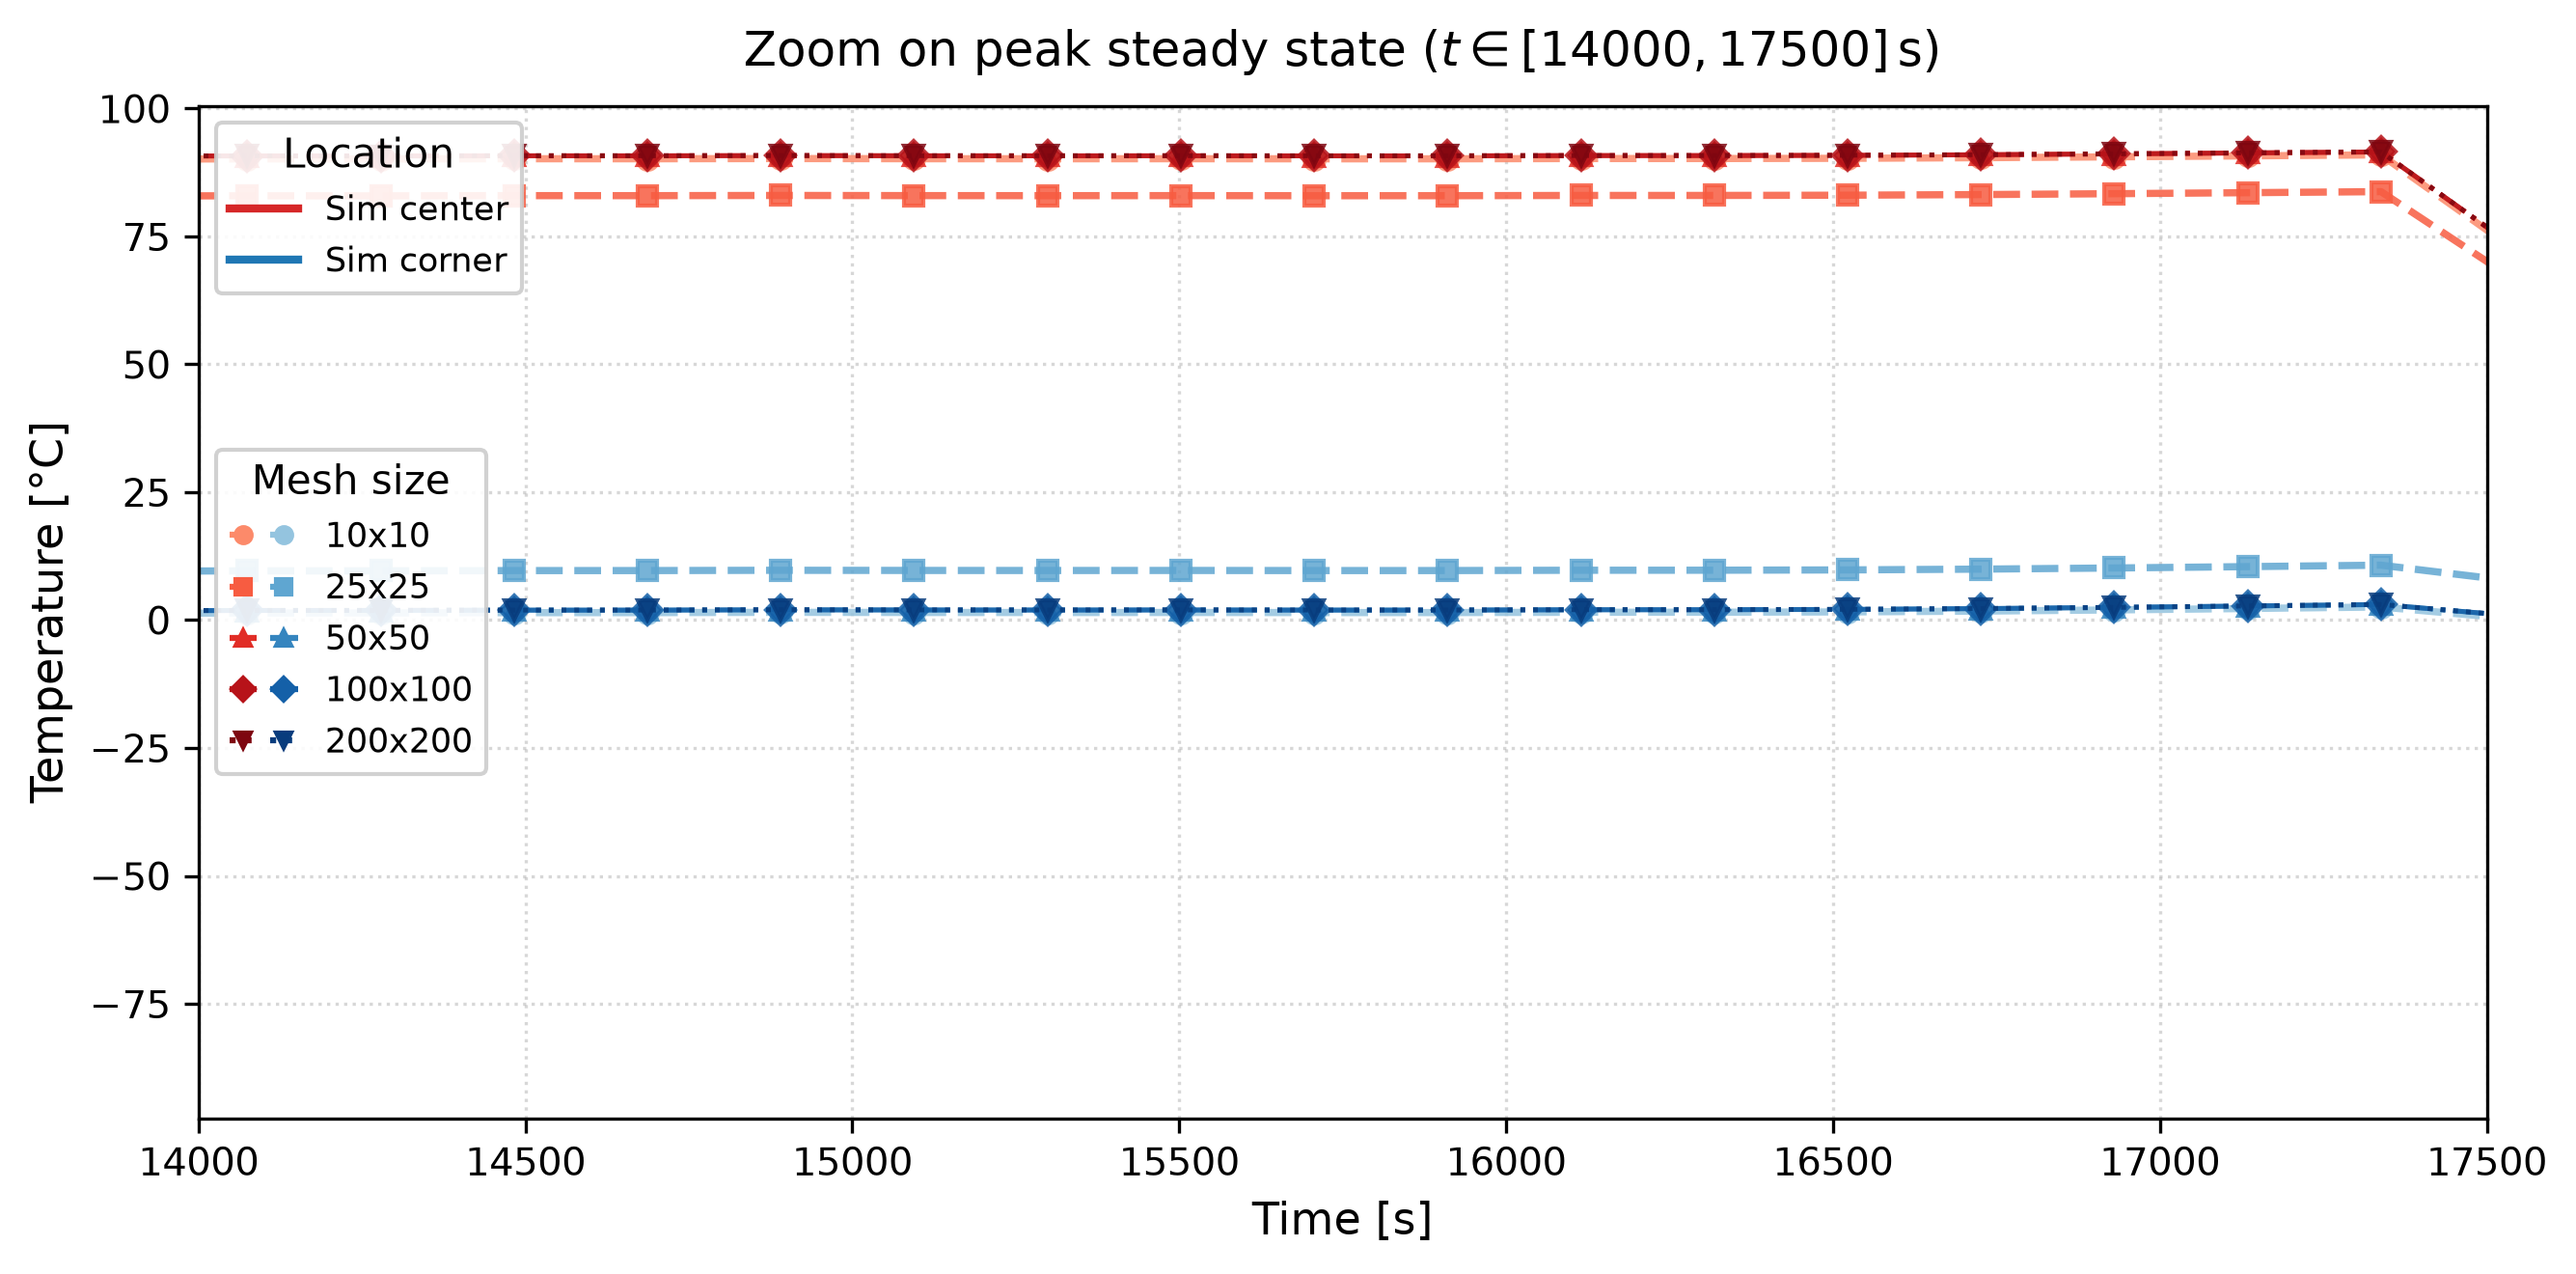

In [12]:
# ---------------------------------------------------------------------------
# spatial convergence: re-run the implicit solver on a range of mesh sizes
# dt is bumped up to 200 s so the finer meshes don't take forever
# ---------------------------------------------------------------------------

dt = 200.0
time_total = min(time_pwr_sec[-1], time_rad_sec[-1])
Nt = int(time_total / dt)
time_array = np.linspace(0, time_total, Nt)

# re-interpolate the inputs onto the coarser grid
T_shroud_real = np.interp(time_array, time_rad_sec, T_shroud_eff_K)
exp_center_C = np.interp(time_array, time_rad_sec, df_filt["Green Center"].values)
exp_corner_C = np.interp(time_array, time_rad_sec, df_filt["Green Corner (back)"].values)
P_step = np.array([get_step_power(t) for t in time_array])

mesh_sizes = [10, 25, 50, 100, 200]
results = {}
exec_times = {}

print(f"Running spatial convergence study (dt = {dt}s, {Nt} steps)...")

for N in mesh_sizes:
    t0 = time.time()
    Nx, Ny = N, N
    N_nodes = Nx * Ny
    dx, dy = L / Nx, W / Ny
    A_node = dx * dy

    x = np.linspace(dx / 2, L - dx / 2, Nx)
    y = np.linspace(dy / 2, W - dy / 2, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')

    heater_mask = ((np.abs(X - L / 2) <= heater_side / 2) & (np.abs(Y - W / 2) <= heater_side / 2)).flatten()
    num_heated_nodes = np.sum(heater_mask)

    C_node = rho * (dx * dy * e) * cp
    Gx = k * e * (dy / dx)
    Gy = k * e * (dx / dy)

    T_vec = np.ones(N_nodes) * T_init_K
    T_center_hist = np.zeros(Nt)
    T_corner_hist = np.zeros(Nt)

    for step in range(Nt):
        T_env = T_shroud_real[step]

        P_eff = P_step[step] * efficiency
        P_per_node = (P_eff / num_heated_nodes) if num_heated_nodes > 0 else 0.0
        Q_heat = heater_mask * P_per_node

        # linearize radiation around T^n
        h_rad_eq = 4.0 * emissivity * sigma * A_node * (T_vec**3)
        Q_rad_n = emissivity * sigma * A_node * (T_vec**4 - T_env**4)

        A = lil_matrix((N_nodes, N_nodes))
        B = np.zeros(N_nodes)

        for i in range(Nx):
            for j in range(Ny):
                p = get_index(i, j)
                diag_val = (C_node / dt) + h_rad_eq[p]

                if i > 0:
                    A[p, get_index(i - 1, j)] = -Gx
                    diag_val += Gx
                if i < Nx - 1:
                    A[p, get_index(i + 1, j)] = -Gx
                    diag_val += Gx
                if j > 0:
                    A[p, get_index(i, j - 1)] = -Gy
                    diag_val += Gy
                if j < Ny - 1:
                    A[p, get_index(i, j + 1)] = -Gy
                    diag_val += Gy

                A[p, p] = diag_val
                B[p] = (C_node / dt) * T_vec[p] + Q_heat[p] - Q_rad_n[p] + h_rad_eq[p] * T_vec[p]

        T_vec = spsolve(A.tocsr(), B)

        T_mat = T_vec.reshape((Nx, Ny)) - 273.15
        T_center_hist[step] = T_mat[Nx // 2, Ny // 2]
        T_corner_hist[step] = T_mat[0, 0]

    exec_times[N] = time.time() - t0
    print(f" -> mesh {N:3d}x{N:<3d} done in {exec_times[N]:.2f}s")

    results[N] = {'center': T_center_hist, 'corner': T_corner_hist}

# ---------------------------------------------------------------------------
# convergence metrics table
# ---------------------------------------------------------------------------

def compute_metrics(sim_arr, exp_arr):
    err = np.abs(sim_arr - exp_arr)
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(err)
    return rmse, mae

summary_data = []
for N in mesh_sizes:
    rmse_c, mae_c = compute_metrics(results[N]['center'], exp_center_C)
    rmse_co, mae_co = compute_metrics(results[N]['corner'], exp_corner_C)
    summary_data.append({
        "Mesh size": f"{N}x{N}",
        "Center RMSE [°C]": rmse_c,
        "Center MAE [°C]": mae_c,
        "Corner RMSE [°C]": rmse_co,
        "Corner MAE [°C]": mae_co,
        "CPU time [s]": exec_times[N]
    })

df_convergence = pd.DataFrame(summary_data).set_index("Mesh size")

print("\nMesh spatial convergence metrics")
print(df_convergence)

# ---------------------------------------------------------------------------
# plots: global transient + zoom on the peak region
# ---------------------------------------------------------------------------

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 8.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'figure.autolayout': True
})

num_m = len(mesh_sizes)
red_shades = [plt.cm.Reds(val) for val in np.linspace(0.4, 0.95, num_m)]
blue_shades = [plt.cm.Blues(val) for val in np.linspace(0.4, 0.95, num_m)]

markers = ['o', 's', '^', 'D', 'v', 'p']
styles = ['--', '--', '-.', '-.', ':']

# figure 1: global view
fig, ax = plt.subplots(figsize=(10, 5.2), dpi=300)
mesh_handles = []

for idx, N in enumerate(mesh_sizes):
    m_style = markers[idx]
    l_style = styles[idx]
    lw = 1.2 if N >= 50 else 1.8

    ax.plot(time_array, results[N]['center'],
            color=red_shades[idx], linewidth=lw, linestyle=l_style,
            marker=m_style, markevery=3, markersize=4.5, alpha=0.85)

    ax.plot(time_array, results[N]['corner'],
            color=blue_shades[idx], linewidth=lw, linestyle=l_style,
            marker=m_style, markevery=3, markersize=4.5, alpha=0.85)

    h_red = plt.Line2D([0], [0], color=red_shades[idx], lw=1.5, linestyle=l_style, marker=m_style, markersize=4)
    h_blue = plt.Line2D([0], [0], color=blue_shades[idx], lw=1.5, linestyle=l_style, marker=m_style, markersize=4)
    mesh_handles.append((h_red, h_blue))

# experimental reference
ax.plot(time_rad_sec, df_filt["Green Center"], color='black', linestyle=':', linewidth=1.5, label='Exp ref: center')
ax.plot(time_rad_sec, df_filt["Green Corner (back)"], color='gray', linestyle=':', linewidth=1.5, label='Exp ref: corner')

ax.set_title(rf'Implicit spatial mesh convergence ($\Delta t = {int(dt)}\,\mathrm{{s}}$, real $T_{{shroud}}$)', pad=10)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Temperature [°C]')
ax.grid(True, linestyle=':', alpha=0.5)

line_center_label = plt.Line2D([0], [0], color='#d62728', lw=2.0, label='Sim center')
line_corner_label = plt.Line2D([0], [0], color='#1f77b4', lw=2.0, label='Sim corner')
leg1 = ax.legend(handles=[line_center_label, line_corner_label],
                 loc='upper left', frameon=True, facecolor='white', framealpha=0.9, title='Location')
ax.add_artist(leg1)

labels_mesh = [f'{N}x{N}' for N in mesh_sizes]
ax.legend(mesh_handles, labels_mesh,
          loc='lower right', frameon=True, facecolor='white', framealpha=0.9,
          ncol=2, title='Mesh size (center | corner)', handler_map={tuple: HandlerTuple(ndivide=None)})

plt.tight_layout()
plt.show()

# figure 2: zoom on the steady-state peak
fig, ax_zoom = plt.subplots(figsize=(9, 4.5), dpi=300)
t_min_zoom, t_max_zoom = 14000, 17500

for idx, N in enumerate(mesh_sizes):
    m_style = markers[idx]
    l_style = styles[idx]
    lw = 1.2 if N >= 50 else 1.8

    ax_zoom.plot(time_array, results[N]['center'],
                 color=red_shades[idx], linewidth=lw, linestyle=l_style,
                 marker=m_style, markevery=1, markersize=5, alpha=0.85)
    ax_zoom.plot(time_array, results[N]['corner'],
                 color=blue_shades[idx], linewidth=lw, linestyle=l_style,
                 marker=m_style, markevery=1, markersize=5, alpha=0.85)

ax_zoom.set_xlim(t_min_zoom, t_max_zoom)
ax_zoom.set_title(r'Zoom on peak steady state ($t \in [14000, 17500]\,\mathrm{s}$)', pad=10)
ax_zoom.set_xlabel('Time [s]')
ax_zoom.set_ylabel('Temperature [°C]')
ax_zoom.grid(True, linestyle=':', alpha=0.5)

leg_zoom1 = ax_zoom.legend(handles=[line_center_label, line_corner_label],
                           loc='upper left', frameon=True, facecolor='white', framealpha=0.9, title='Location')
ax_zoom.add_artist(leg_zoom1)

ax_zoom.legend(mesh_handles, labels_mesh,
               loc='center left', frameon=True, facecolor='white', framealpha=0.9,
               title='Mesh size', handler_map={tuple: HandlerTuple(ndivide=None)})

plt.tight_layout()
plt.show()

In [13]:
# ---------------------------------------------------------------------------
# relative error vs the finest mesh (200x200), no re-simulation needed
# ---------------------------------------------------------------------------

ref_N = 200
T_center_ref = results[ref_N]['center']
T_corner_ref = results[ref_N]['corner']

table_data = []

for N in mesh_sizes:
    dx_mm = (L / N) * 1000.0

    if N == ref_N:
        mean_rel_err_center = 0.0
        max_rel_err_center = 0.0
        mean_rel_err_corner = 0.0
        max_rel_err_corner = 0.0
    else:
        # back to Kelvin for a physically meaningful relative error
        T_c = results[N]['center'] + 273.15
        T_c_ref = T_center_ref + 273.15

        T_corn = results[N]['corner'] + 273.15
        T_corn_ref = T_corner_ref + 273.15

        rel_err_center = np.abs((T_c - T_c_ref) / T_c_ref) * 100.0
        rel_err_corner = np.abs((T_corn - T_corn_ref) / T_corn_ref) * 100.0

        mean_rel_err_center = np.mean(rel_err_center)
        max_rel_err_center = np.max(rel_err_center)

        mean_rel_err_corner = np.mean(rel_err_corner)
        max_rel_err_corner = np.max(rel_err_corner)

    table_data.append({
        'Mesh size': f'{N}x{N}',
        'dx (mm)': dx_mm,
        'Mean rel error center (%)': mean_rel_err_center,
        'Max rel error center (%)': max_rel_err_center,
        'Mean rel error corner (%)': mean_rel_err_corner,
        'Max rel error corner (%)': max_rel_err_corner
    })

df_errors = pd.DataFrame(table_data)

print("Relative error table vs 200x200 mesh")

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
df_errors

Relative error table vs 200x200 mesh


,Mesh size,dx (mm),Mean rel error center (%),Max rel error center (%),Mean rel error corner (%),Max rel error corner (%)
0,10x10,10.0000,0.1162,0.1932,0.1133,0.2177
1,25x25,4.0000,1.6453,2.7828,1.8664,3.4108
2,50x50,2.0000,0.0044,0.0075,0.0054,0.0101
3,100x100,1.0000,0.0009,0.0015,0.0011,0.0020
4,200x200,0.5000,0.0000,0.0000,0.0000,0.0000


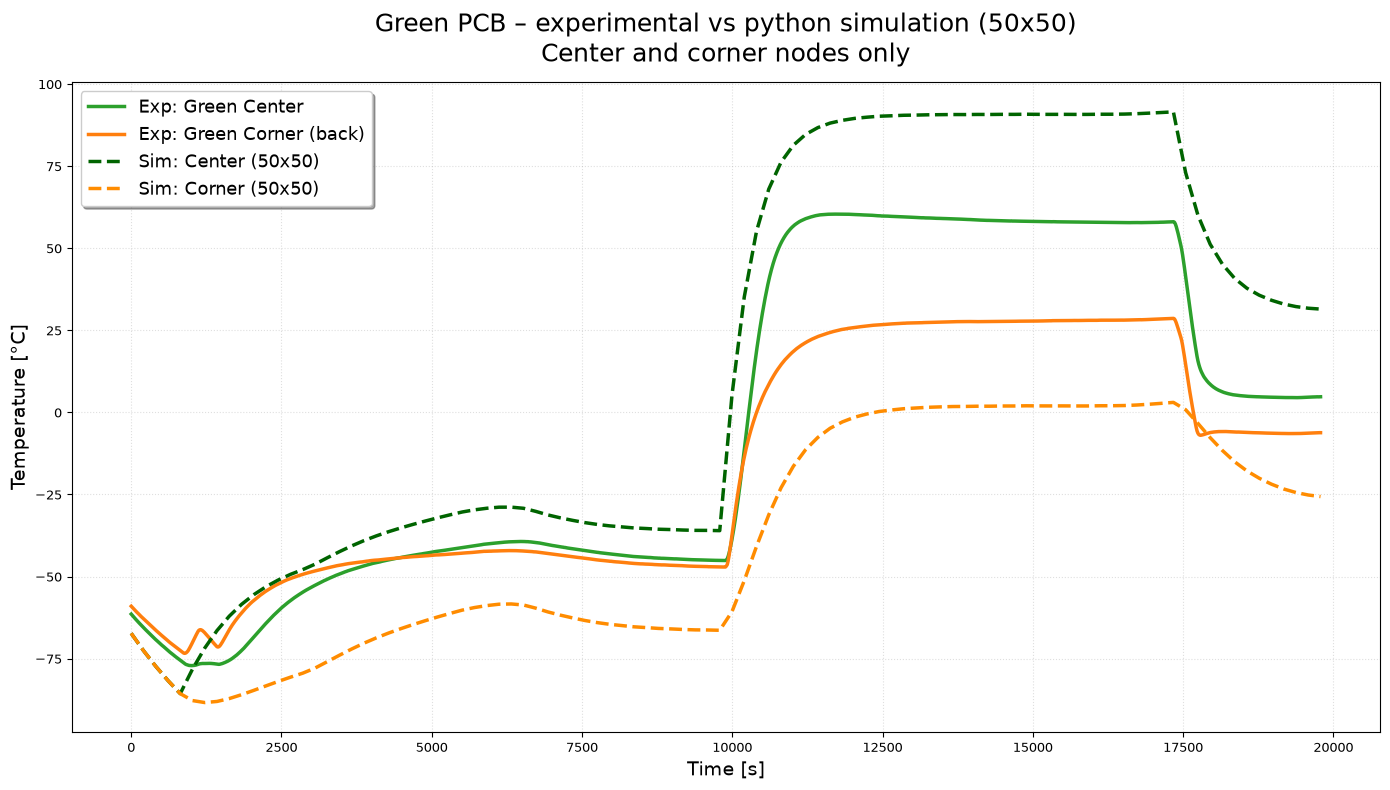

In [14]:
# pick a mesh to plot — 50x50 is a good speed/accuracy trade-off
N_plot = 50

plt.figure(figsize=(14, 8))

# experimental reference curves
if "Green Center" in df_filt.columns:
    plt.plot(time_rad_sec, df_filt["Green Center"], label="Exp: Green Center", color='#2ca02c', linewidth=2.5)

if "Green Corner (back)" in df_filt.columns:
    plt.plot(time_rad_sec, df_filt["Green Corner (back)"], label="Exp: Green Corner (back)", color='#ff7f0e', linewidth=2.5)

# sim curves pulled straight from the stored results
plt.plot(time_array, results[N_plot]['center'], color='darkgreen', linestyle='--', linewidth=2.5, label=f'Sim: Center ({N_plot}x{N_plot})')
plt.plot(time_array, results[N_plot]['corner'], color='darkorange', linestyle='--', linewidth=2.5, label=f'Sim: Corner ({N_plot}x{N_plot})')

plt.xlabel("Time [s]", fontsize=14)
plt.ylabel("Temperature [°C]", fontsize=14)
plt.title(f"Green PCB – experimental vs python simulation ({N_plot}x{N_plot})\nCenter and corner nodes only", fontsize=18, pad=15)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=13, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

In [15]:
# simcenter3D results live in a separate file, one sheet per node
file = "SimcenterData.xlsx"

df_central = pd.read_excel(file, sheet_name="Central")
df_corner  = pd.read_excel(file, sheet_name="Corner")

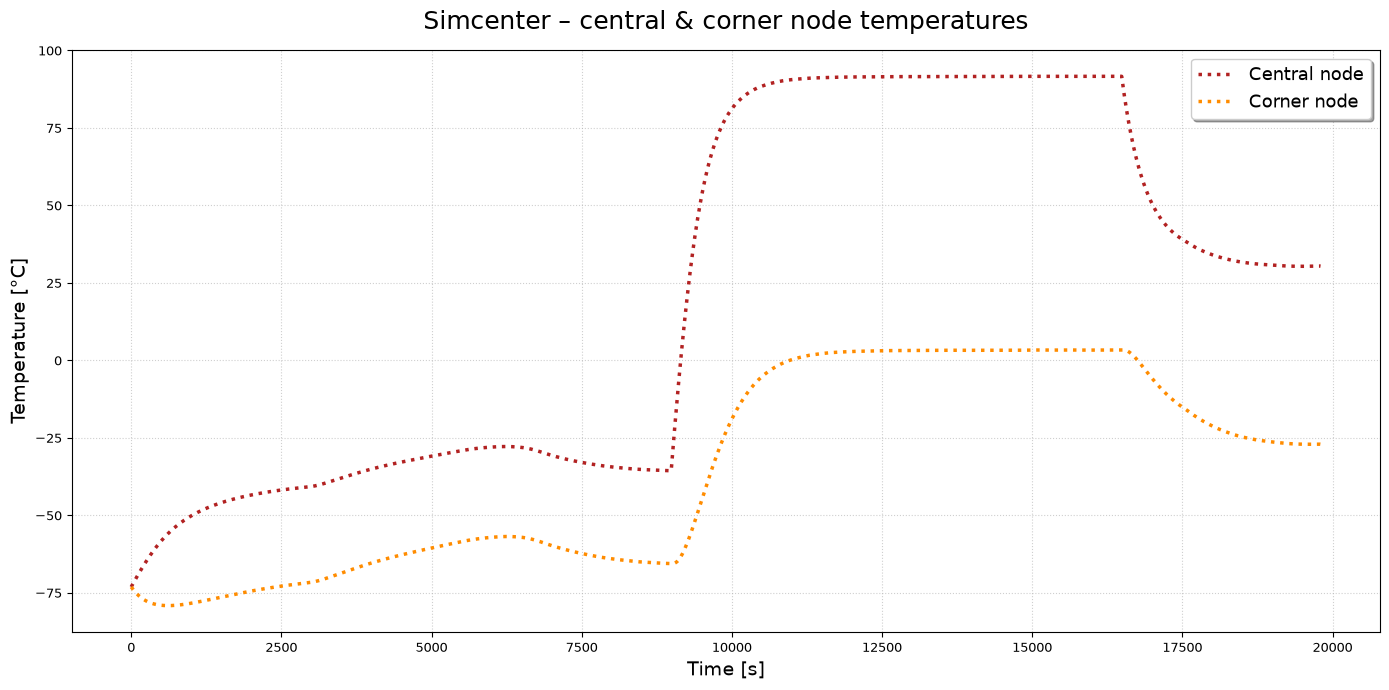

In [16]:
# pull the time/temperature arrays out of each DataFrame
t_central = df_central["Time(s)"].to_numpy()
T_central = df_central["Temperature Nœud Corner(°C)"].to_numpy()

t_corner = df_corner["Time(s)"].to_numpy()
T_corner = df_corner["Temperature Nœud Corner(°C)"].to_numpy()

# trim everything past t = 19800 s to match the experiment window
mask_central = t_central <= 19800
t_central = t_central[mask_central]
T_central = T_central[mask_central]

mask_corner = t_corner <= 19800
t_corner = t_corner[mask_corner]
T_corner = T_corner[mask_corner]

plt.figure(figsize=(14, 7))

plt.plot(t_central, T_central, label="Central node", color="firebrick", linestyle=":", linewidth=2.5)
plt.plot(t_corner, T_corner, label="Corner node", color="darkorange", linestyle=":", linewidth=2.5)

plt.xlabel("Time [s]", fontsize=14)
plt.ylabel("Temperature [°C]", fontsize=14)
plt.title("Simcenter – central & corner node temperatures", fontsize=18, pad=15)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=13, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

Optimal time shift: 0.00 s


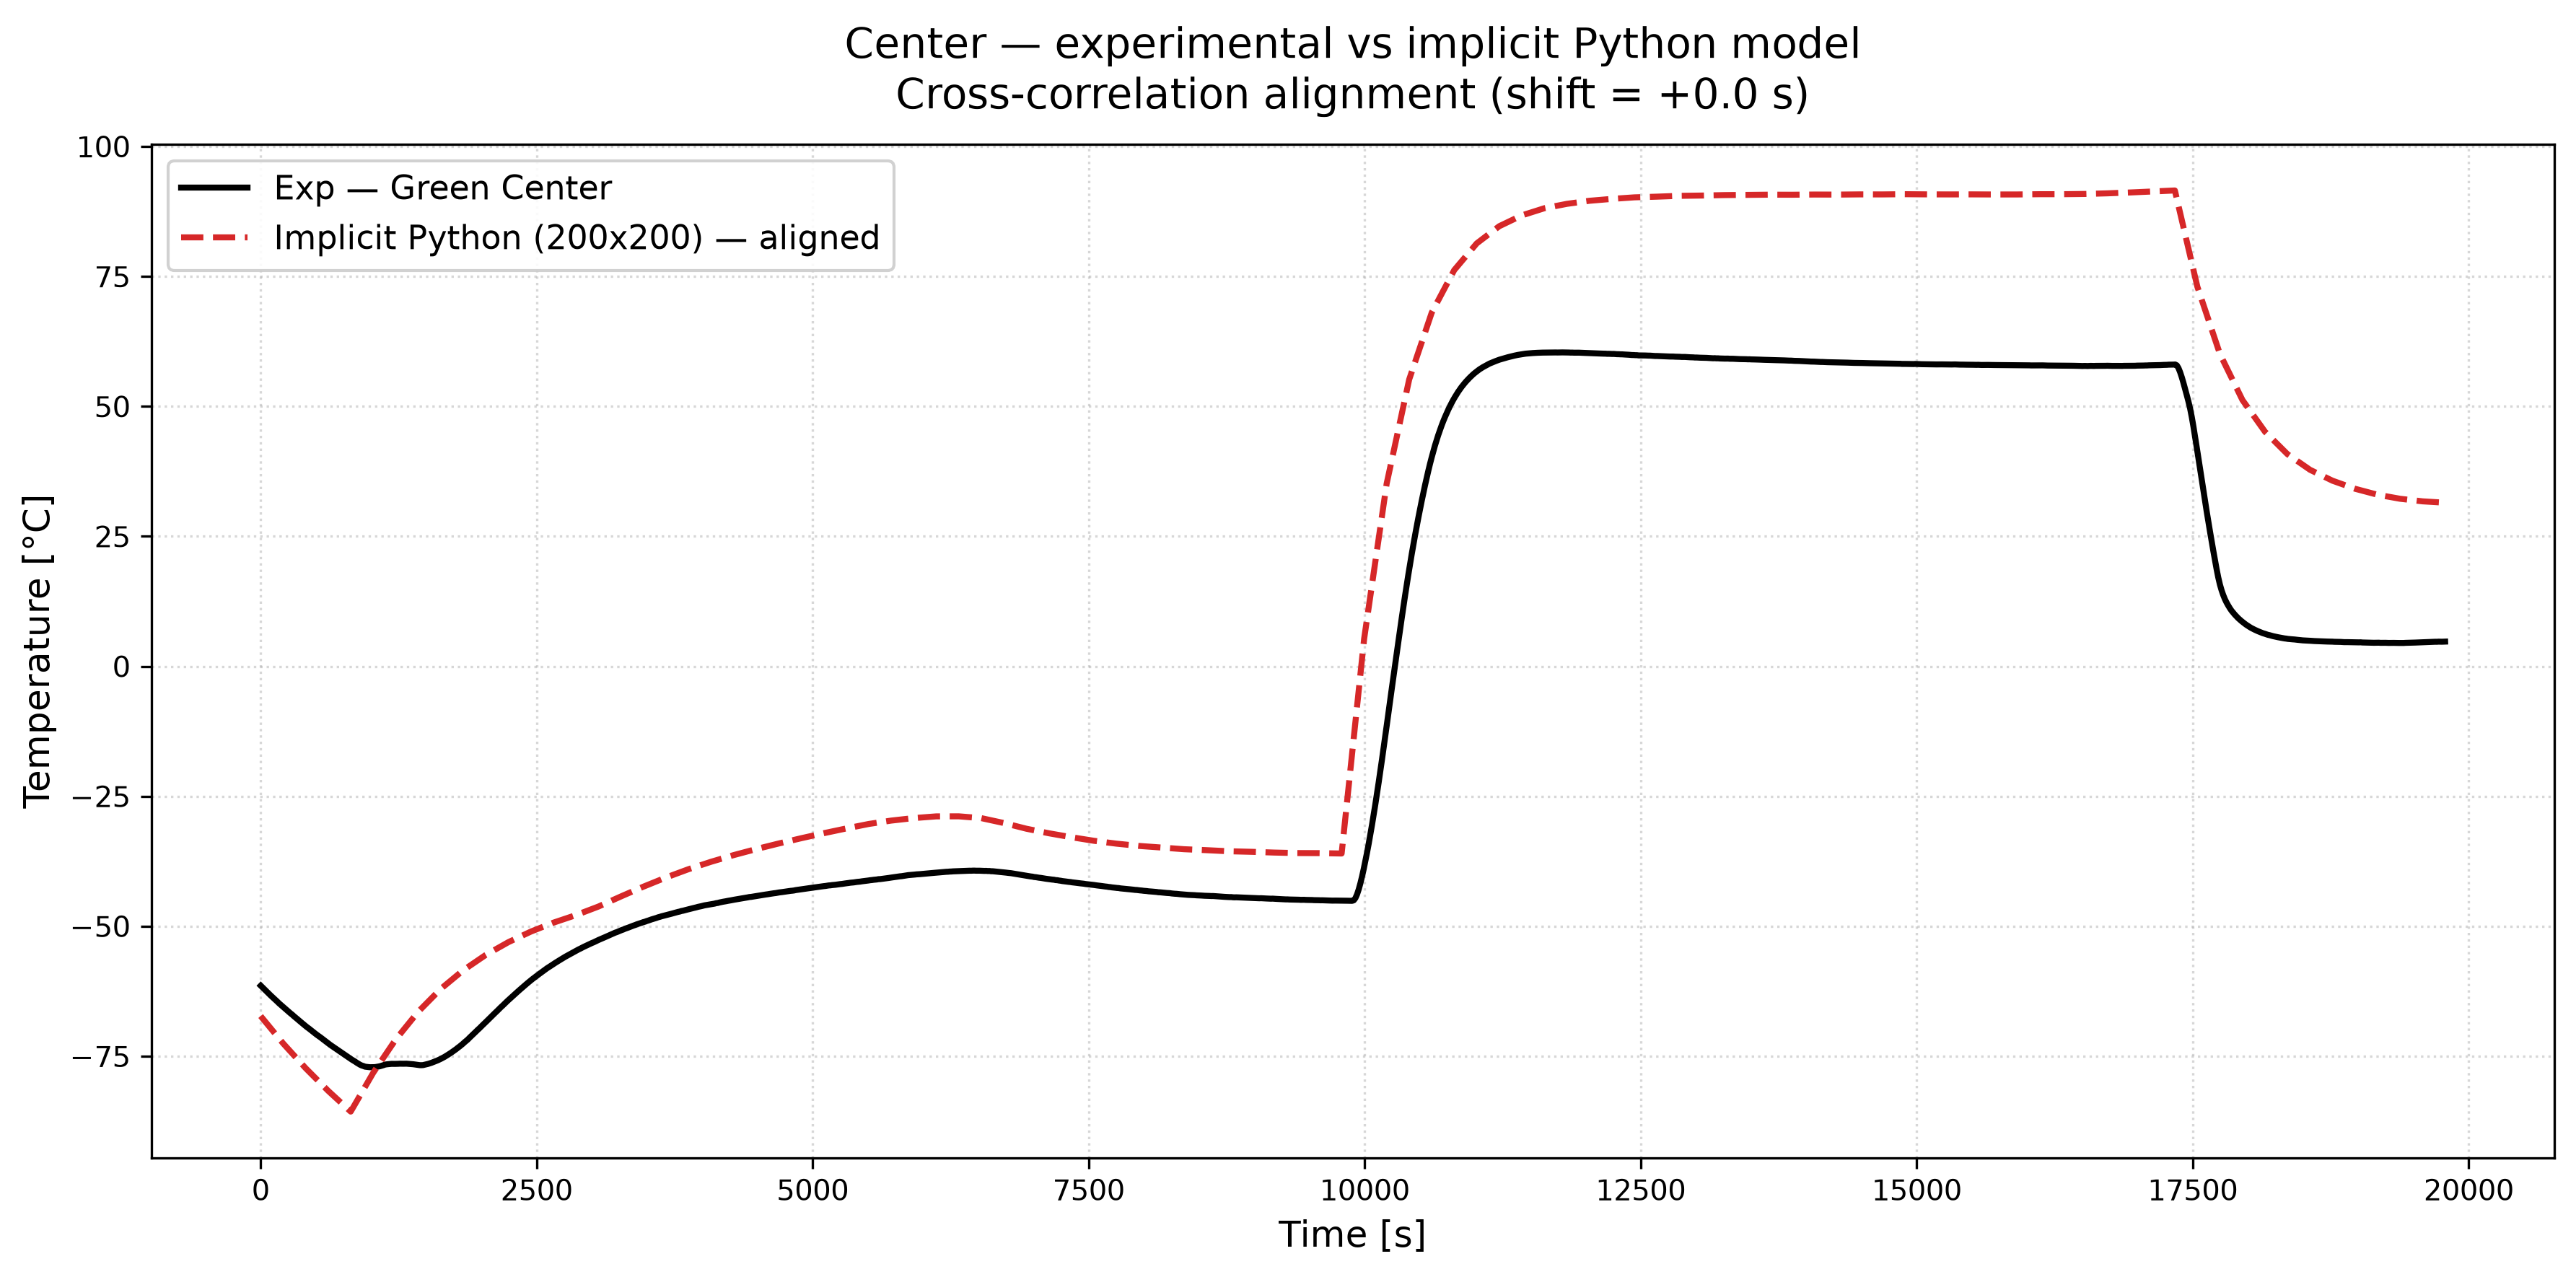

In [17]:
# pick which mesh resolution to compare against the experiment
N_selected = 200

# grab the time + temperature arrays and make sure they're clean floats
t_exp = np.asarray(time_rad_sec, dtype=float)
t_sim_raw = np.asarray(time_array, dtype=float)

exp = np.asarray(df_filt["Green Center"].values, dtype=float)
sim = np.asarray(results[N_selected]['center'], dtype=float)

# the sim array might not line up 1:1 with the time grid, so resample if needed
if len(t_sim_raw) != len(sim):
    print(f"t_sim_raw ({len(t_sim_raw)}) and sim ({len(sim)}) differ in size — resampling t_sim.")
    t_sim = np.linspace(t_sim_raw[0], t_sim_raw[-1], len(sim))
else:
    t_sim = t_sim_raw

# drop any NaNs before interpolating
valid_exp = ~np.isnan(t_exp) & ~np.isnan(exp)
t_exp, exp = t_exp[valid_exp], exp[valid_exp]

valid_sim = ~np.isnan(t_sim) & ~np.isnan(sim)
t_sim, sim = t_sim[valid_sim], sim[valid_sim]

# common time base for both signals
t_common = np.linspace(0, min(t_exp[-1], t_sim[-1]), 5000)

exp_i = np.interp(t_common, t_exp, exp)
sim_i = np.interp(t_common, t_sim, sim)

# find the best time shift via cross-correlation
def best_shift(a, b):
    corr = np.correlate(a - a.mean(), b - b.mean(), mode='full')
    return corr.argmax() - (len(a) - 1)

shift_sim = best_shift(exp_i, sim_i)
dt_common = t_common[1] - t_common[0]
time_shift_sec = shift_sim * dt_common

t_sim_aligned = t_sim + time_shift_sec

print(f"Optimal time shift: {time_shift_sec:.2f} s")

plt.figure(figsize=(12, 6), dpi=300)

plt.plot(t_exp, exp, label="Exp — Green Center", color='black', linewidth=2.0)
plt.plot(t_sim_aligned, sim,
         label=f"Implicit Python ({N_selected}x{N_selected}) — aligned",
         color='#d62728', linestyle='--', linewidth=2.0)

plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Temperature [°C]", fontsize=12)
plt.title(f"Center — experimental vs implicit Python model\n"
          f"Cross-correlation alignment (shift = {time_shift_sec:+.1f} s)",
          fontsize=14, pad=12)

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

Optimal time shift (corner): -205.82 s


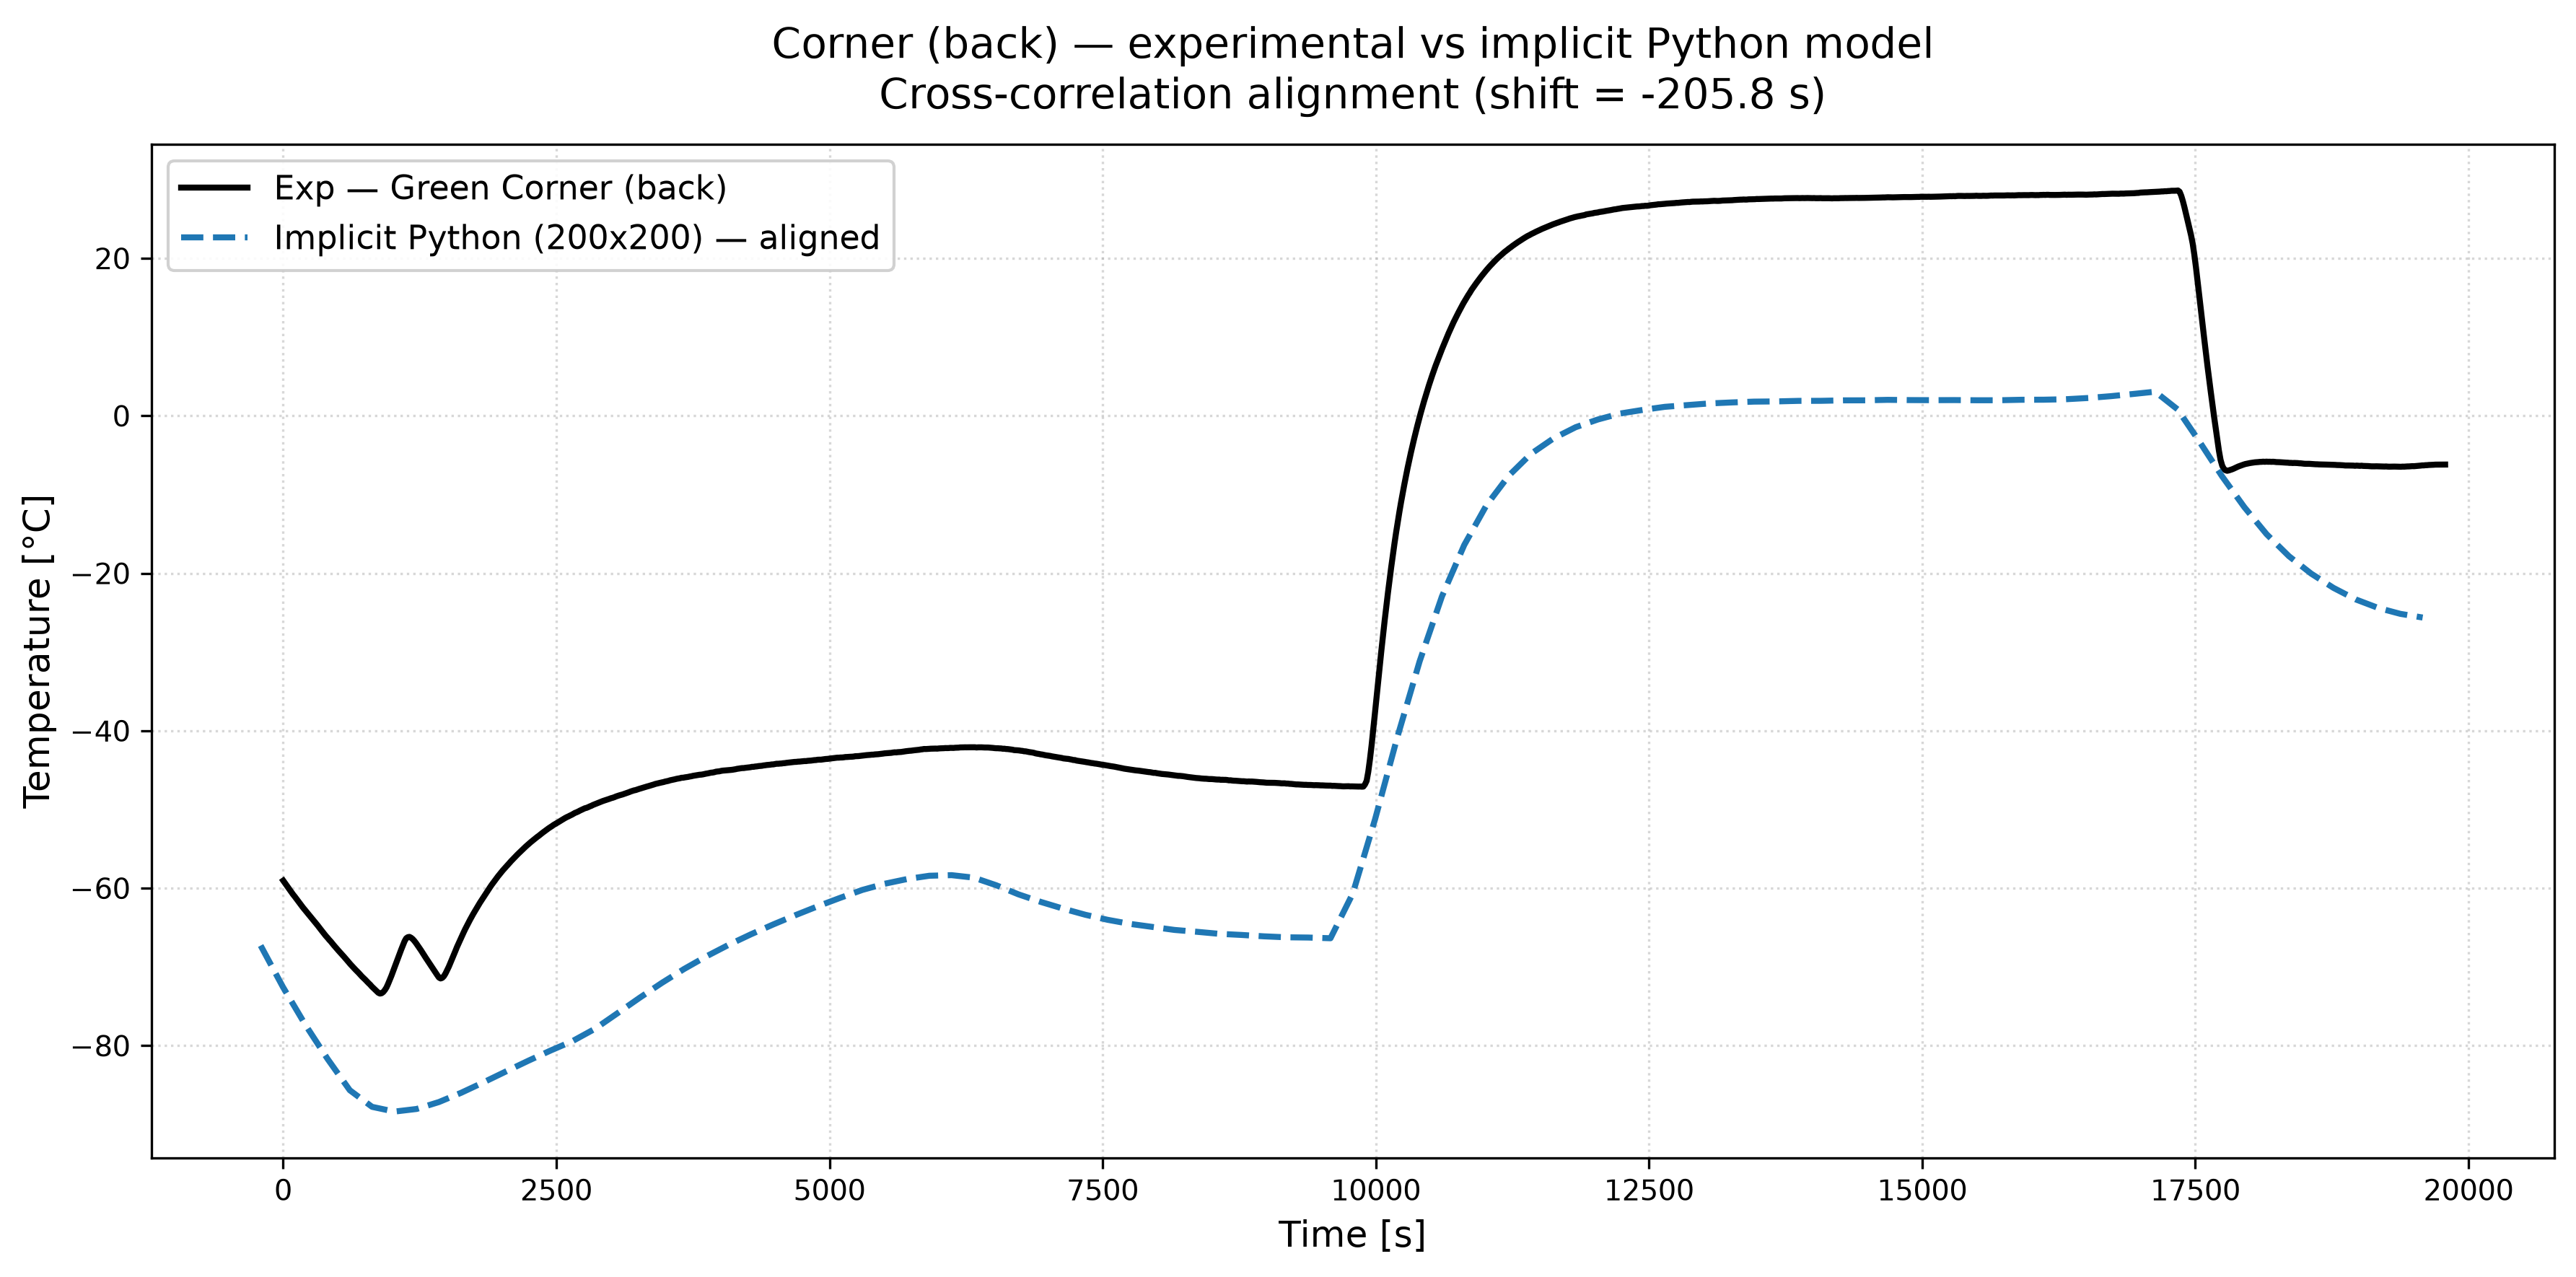

In [18]:
# same idea, but for the corner node this time
N_selected = 200

t_exp = np.asarray(time_rad_sec, dtype=float).ravel()
t_sim_raw = np.asarray(time_array, dtype=float).ravel()

exp = np.asarray(df_filt["Green Corner (back)"].values, dtype=float).ravel()
sim = np.asarray(results[N_selected]['corner'], dtype=float).ravel()

# make sure t_sim matches sim in length, resample if needed
if len(t_sim_raw) != len(sim):
    print(f"t_sim_raw ({len(t_sim_raw)}) and sim ({len(sim)}) differ in size — resampling.")
    t_sim = np.linspace(t_sim_raw[0], t_sim_raw[-1], len(sim))
else:
    t_sim = t_sim_raw

# strip NaNs from both signals
valid_exp = ~np.isnan(t_exp) & ~np.isnan(exp)
t_exp, exp = t_exp[valid_exp], exp[valid_exp]

valid_sim = ~np.isnan(t_sim) & ~np.isnan(sim)
t_sim, sim = t_sim[valid_sim], sim[valid_sim]

# common time base
t_common = np.linspace(0, min(t_exp[-1], t_sim[-1]), 5000)

exp_i = np.interp(t_common, t_exp, exp)
sim_i = np.interp(t_common, t_sim, sim)

# reuse the cross-correlation shift function
shift_sim = best_shift(exp_i, sim_i)
dt_common = t_common[1] - t_common[0]
time_shift_sec = shift_sim * dt_common

t_sim_aligned = t_sim + time_shift_sec

print(f"Optimal time shift (corner): {time_shift_sec:.2f} s")

plt.figure(figsize=(12, 6), dpi=300)

plt.plot(t_exp, exp, label="Exp — Green Corner (back)", color='black', linewidth=2.0)
plt.plot(t_sim_aligned, sim,
         label=f"Implicit Python ({N_selected}x{N_selected}) — aligned",
         color='#1f77b4', linestyle='--', linewidth=2.0)

plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Temperature [°C]", fontsize=12)
plt.title(f"Corner (back) — experimental vs implicit Python model\n"
          f"Cross-correlation alignment (shift = {time_shift_sec:+.1f} s)",
          fontsize=14, pad=12)

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

Shift center: 155.23 s | Shift corner: -38.81 s


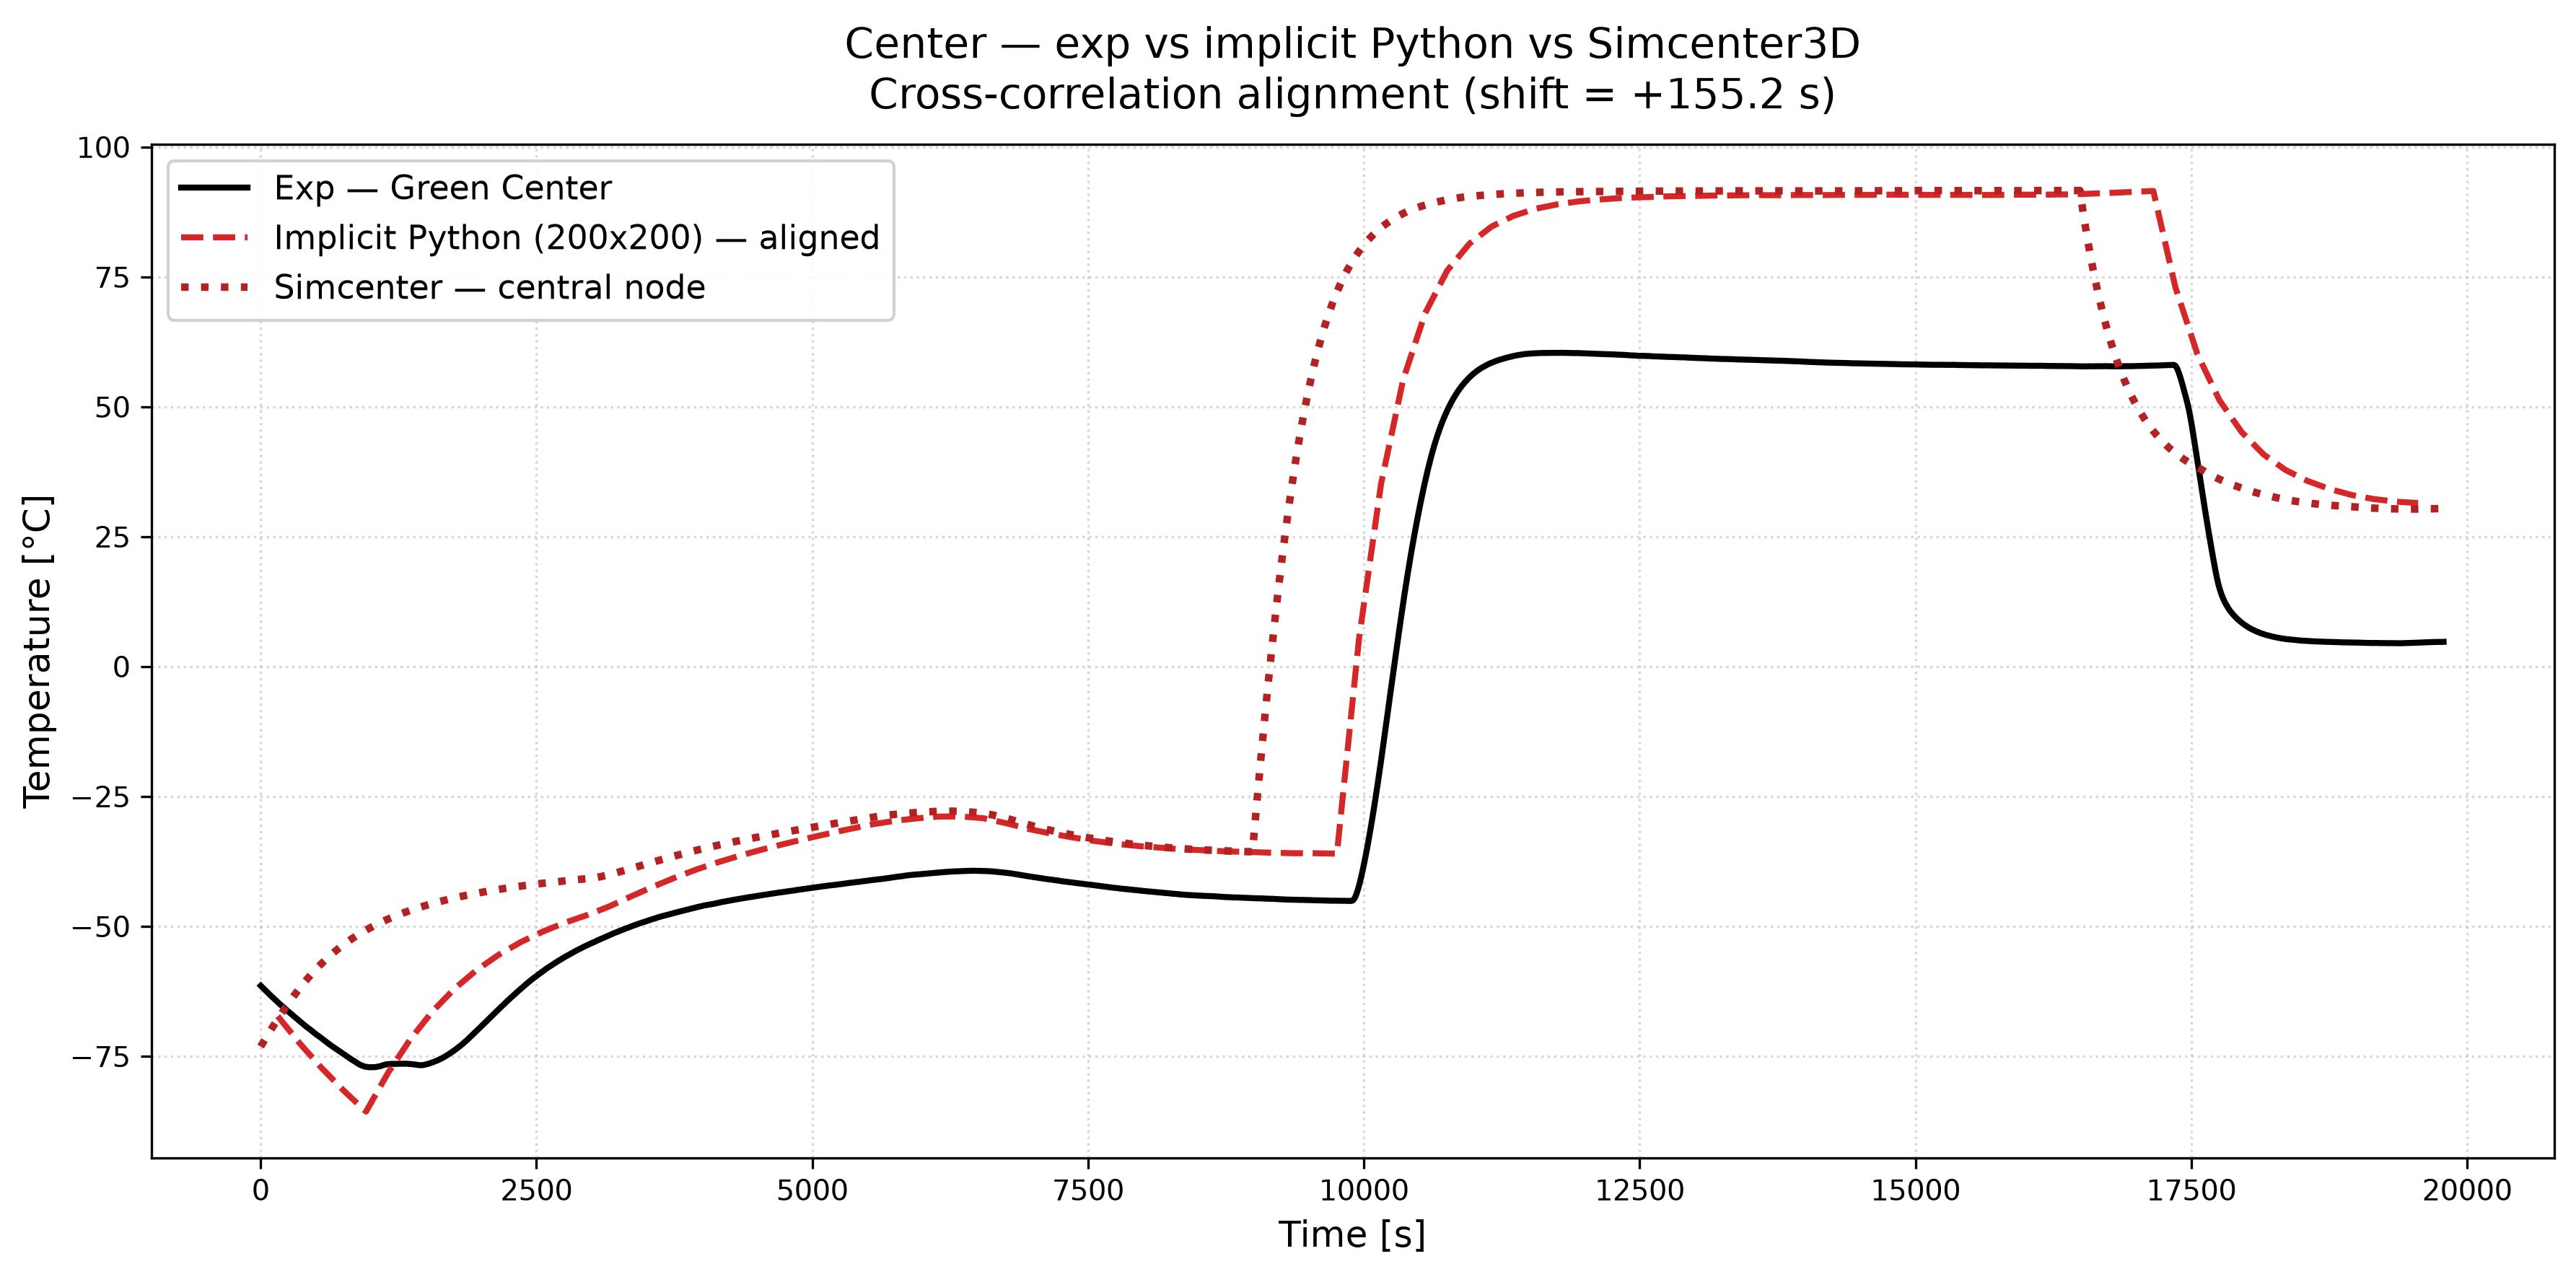

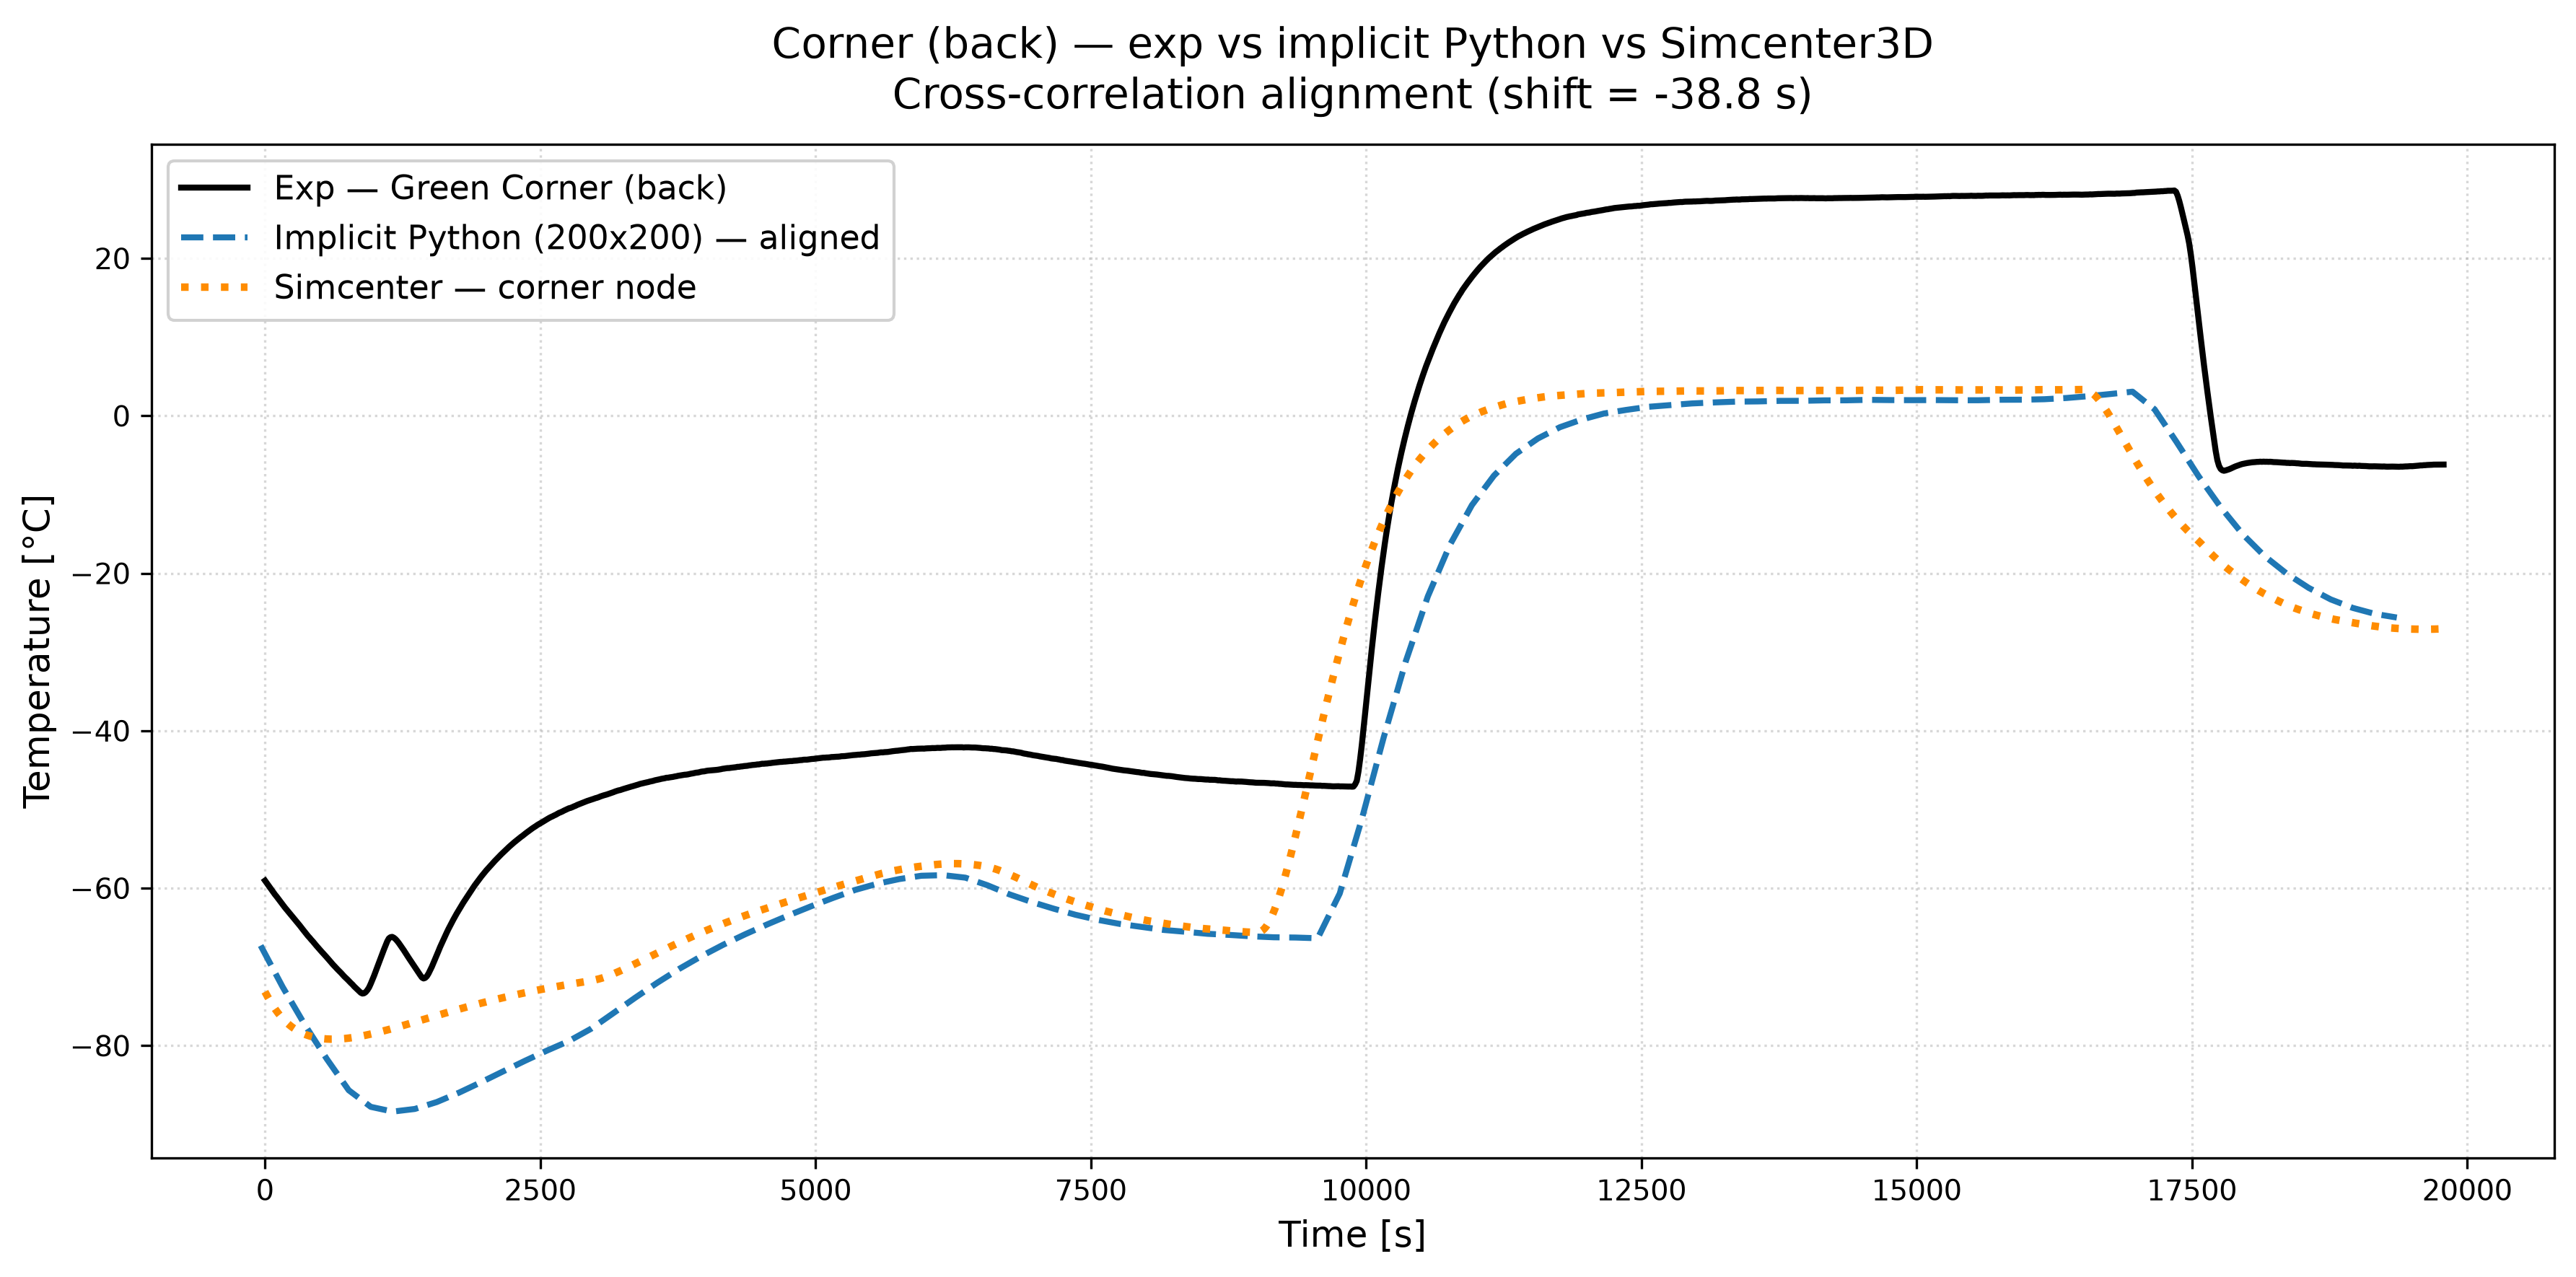

In [19]:
# ---------------------------------------------------------------------------
# 1. EXPERIMENTAL (réel)
# ---------------------------------------------------------------------------
t_exp = np.asarray(time_rad_sec, dtype=float).ravel()
exp_center = np.asarray(df_filt["Green Center"].values, dtype=float).ravel()
exp_corner = np.asarray(df_filt["Green Corner (back)"].values, dtype=float).ravel()

# ---------------------------------------------------------------------------
# 2. PYTHON — results[200] déjà en mémoire, on reconstruit t_sim à sa longueur
# ---------------------------------------------------------------------------
sim_center = np.asarray(results[200]['center'], dtype=float).ravel()
sim_corner = np.asarray(results[200]['corner'], dtype=float).ravel()

# results[200] a été calculé avec dt=200s, time_array a pu changer depuis
# on reconstruit la grille temporelle qui correspond à results[200]
t_sim = np.linspace(0, (len(sim_center) - 1) * 200.0, len(sim_center))

# ---------------------------------------------------------------------------
# CROSS-CORRELATION ALIGNMENT
# ---------------------------------------------------------------------------

# center
t_common_c = np.linspace(0, min(t_exp[-1], t_sim[-1]), 5000)
exp_i_c = np.interp(t_common_c, t_exp, exp_center)
sim_i_c = np.interp(t_common_c, t_sim, sim_center)

shift_center = best_shift(exp_i_c, sim_i_c) * (t_common_c[1] - t_common_c[0])
t_sim_aligned_center = t_sim + shift_center

# corner
t_common_co = np.linspace(0, min(t_exp[-1], t_sim[-1]), 5000)
exp_i_co = np.interp(t_common_co, t_exp, exp_corner)
sim_i_co = np.interp(t_common_co, t_sim, sim_corner)

shift_corner = best_shift(exp_i_co, sim_i_co) * (t_common_co[1] - t_common_co[0])
t_sim_aligned_corner = t_sim + shift_corner

print(f"Shift center: {shift_center:.2f} s | Shift corner: {shift_corner:.2f} s")

# ---------------------------------------------------------------------------
# PLOTS — Exp vs Python (200x200, aligned) vs Simcenter3D
# ---------------------------------------------------------------------------

# center node
plt.figure(figsize=(12, 6), dpi=300)
plt.plot(t_exp, exp_center, label="Exp — Green Center", color='black', linewidth=2.0)
plt.plot(t_sim_aligned_center, sim_center, label="Implicit Python (200x200) — aligned", color='#d62728', linestyle='--', linewidth=2.0)
plt.plot(t_central, T_central, label="Simcenter — central node", color='firebrick', linestyle=':', linewidth=2.5)

plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Temperature [°C]", fontsize=12)
plt.title(f"Center — exp vs implicit Python vs Simcenter3D\n"
          f"Cross-correlation alignment (shift = {shift_center:+.1f} s)", fontsize=14, pad=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

# corner node
plt.figure(figsize=(12, 6), dpi=300)
plt.plot(t_exp, exp_corner, label="Exp — Green Corner (back)", color='black', linewidth=2.0)
plt.plot(t_sim_aligned_corner, sim_corner, label="Implicit Python (200x200) — aligned", color='#1f77b4', linestyle='--', linewidth=2.0)
plt.plot(t_corner, T_corner, label="Simcenter — corner node", color='darkorange', linestyle=':', linewidth=2.5)

plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Temperature [°C]", fontsize=12)
plt.title(f"Corner (back) — exp vs implicit Python vs Simcenter3D\n"
          f"Cross-correlation alignment (shift = {shift_corner:+.1f} s)", fontsize=14, pad=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

In [20]:
import casadi as ca

# ---------------------------------------------------------------------------
# CasADi MDAO: parameter identification via collocation integrator + IPOPT
# ---------------------------------------------------------------------------

# physical + mesh constants already defined: rho, L, W, e, sigma
# bounds for the three free parameters
cp_min, cp_max   = 700.0, 1200.0
k_min, k_max     = 0.2, 0.8
eps_min, eps_max = 0.6, 0.95

Nx, Ny = 20, 20
dx, dy = L / Nx, W / Ny

# stride the experimental time grid to keep the symbolic graph manageable
step_stride = 30
time_exp_full = np.asarray(time_rad_sec, dtype=float)
time_grid = time_exp_full[::step_stride]
dt_step = time_grid[1] - time_grid[0]
Nt_sub = len(time_grid)

# shroud + experimental targets, sub-sampled to match
T_top_K = df_filt["Shroud Top"].values[::step_stride] + 273.15
T_bot_K = df_filt["Shroud Bottom"].values[::step_stride] + 273.15
T_shroud_eff_K = (0.5 * (T_top_K**4) + 0.5 * (T_bot_K**4))**(1/4)

T_center_exp = df_filt["Green Center"].values[::step_stride]
T_corner_exp = df_filt["Green Corner (back)"].values[::step_stride]

# heater mask on the optimization mesh
x = np.linspace(dx/2, L - dx/2, Nx)
y = np.linspace(dy/2, W - dy/2, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')
heater_mask = ((np.abs(X - L/2) <= heater_side/2) & (np.abs(Y - W/2) <= heater_side/2)).astype(float)
num_heated_nodes = float(np.sum(heater_mask))

# step power profile, pre-applied with efficiency
P_eff_exp = np.array([get_step_power(t) for t in time_grid]) * 0.6
T_init_K = df_filt["Green Center"].iloc[0] + 273.15

# ---------------------------------------------------------------------------
# symbolic model: state T, parameters p = [cp, k, eps, P_heat, T_env]
# ---------------------------------------------------------------------------

T_vec = ca.MX.sym('T_vec', Nx * Ny)
p_params = ca.MX.sym('p', 5)

cp_s, k_s, eps_s, P_heat_s, T_env_s = [p_params[i] for i in range(5)]
T_2d = ca.reshape(T_vec, Nx, Ny)

# conduction with Neumann (edge-padded) BCs
T_pad = ca.MX.zeros(Nx + 2, Ny + 2)
T_pad[1:-1, 1:-1] = T_2d
T_pad[0, 1:-1] = T_2d[0, :]
T_pad[-1, 1:-1] = T_2d[-1, :]
T_pad[1:-1, 0] = T_2d[:, 0]
T_pad[1:-1, -1] = T_2d[:, -1]

Q_cond = (k_s * e * (dy/dx) * (T_pad[1:-1, :-2] + T_pad[1:-1, 2:] - 2*T_2d) +
          k_s * e * (dx/dy) * (T_pad[2:, 1:-1] + T_pad[:-2, 1:-1] - 2*T_2d))
Q_rad = eps_s * sigma * (dx * dy) * (T_2d**4 - T_env_s**4)
Q_heat = heater_mask * (P_heat_s / num_heated_nodes if num_heated_nodes > 0 else 0.0)

C_node = rho * (dx * dy * e) * cp_s
dTdt = (Q_cond + Q_heat - Q_rad) / C_node

ode = ca.reshape(dTdt, Nx * Ny, 1)

dae = {'x': T_vec, 'p': p_params, 'ode': ode}

# collocation integrator (unconditionally stable, no NaN blow-up)
integrator = ca.integrator('F', 'collocation', dae, 0.0, dt_step, {'number_of_finite_elements': 1})

# ---------------------------------------------------------------------------
# optimization problem: minimize SSE vs experimental center + corner
# ---------------------------------------------------------------------------

opti = ca.Opti()

cp_var  = opti.variable()
k_var   = opti.variable()
eps_var = opti.variable()

opti.subject_to(opti.bounded(cp_min, cp_var, cp_max))
opti.subject_to(opti.bounded(k_min, k_var, k_max))
opti.subject_to(opti.bounded(eps_min, eps_var, eps_max))

T_curr = ca.MX.ones(Nx * Ny, 1) * T_init_K

idx_center = (Nx // 2) * Ny + (Ny // 2)
idx_corner = 0

J = 0

for i in range(Nt_sub - 1):
    p_k = ca.vertcat(cp_var, k_var, eps_var, P_eff_exp[i], T_shroud_eff_K[i])

    res = integrator(x0=T_curr, p=p_k)
    T_curr = res['xf']

    T_sim_c = T_curr[idx_center] - 273.15
    T_sim_cor = T_curr[idx_corner] - 273.15

    J += (T_sim_c - T_center_exp[i+1])**2 + (T_sim_cor - T_corner_exp[i+1])**2

opti.minimize(J)

opti.set_initial(cp_var, 900.0)
opti.set_initial(k_var, 0.5)
opti.set_initial(eps_var, 0.9)

opti.solver('ipopt', {'expand': True, 'ipopt.max_iter': 50, 'ipopt.print_level': 5})

sol = opti.solve()

cp_opt  = sol.value(cp_var)
k_opt   = sol.value(k_var)
eps_opt = sol.value(eps_var)

print("\n=== Optimization results ===")
print(f"cp_opt  = {cp_opt:.2f} J/(kg·K)")
print(f"k_opt   = {k_opt:.3f} W/(m·K)")
print(f"eps_opt = {eps_opt:.3f}")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:        6

Total number of variables............................:        3
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality c

Running implicit solver (50x50, dt = 50s, optimized params)...
  cp = 842.32 | k = 0.8000 | emissivity = 0.9314
Shift center: 0.00 s | Shift corner: -201.86 s


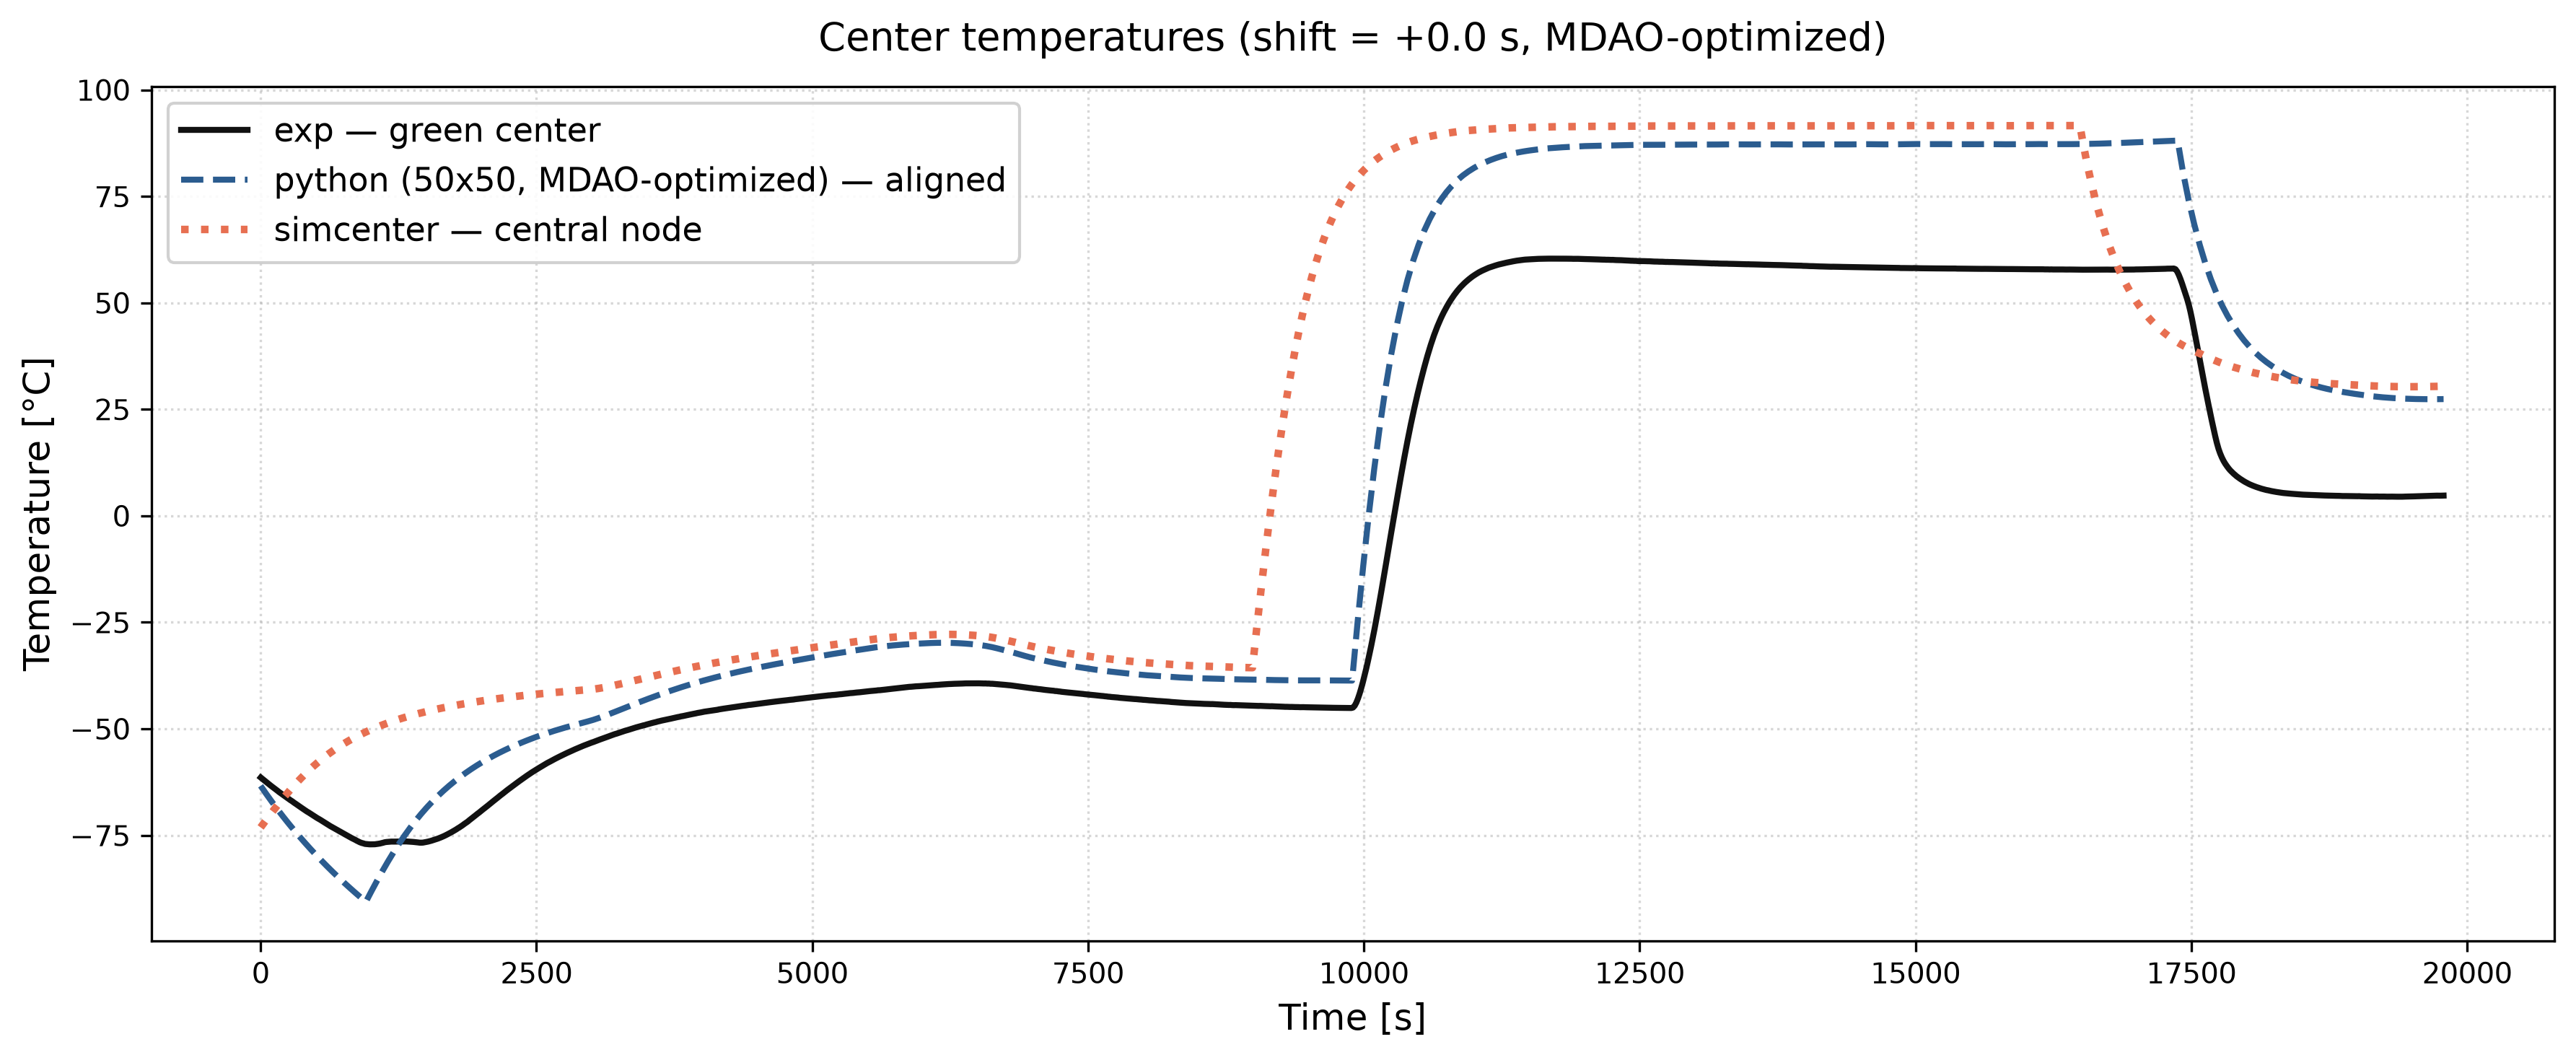

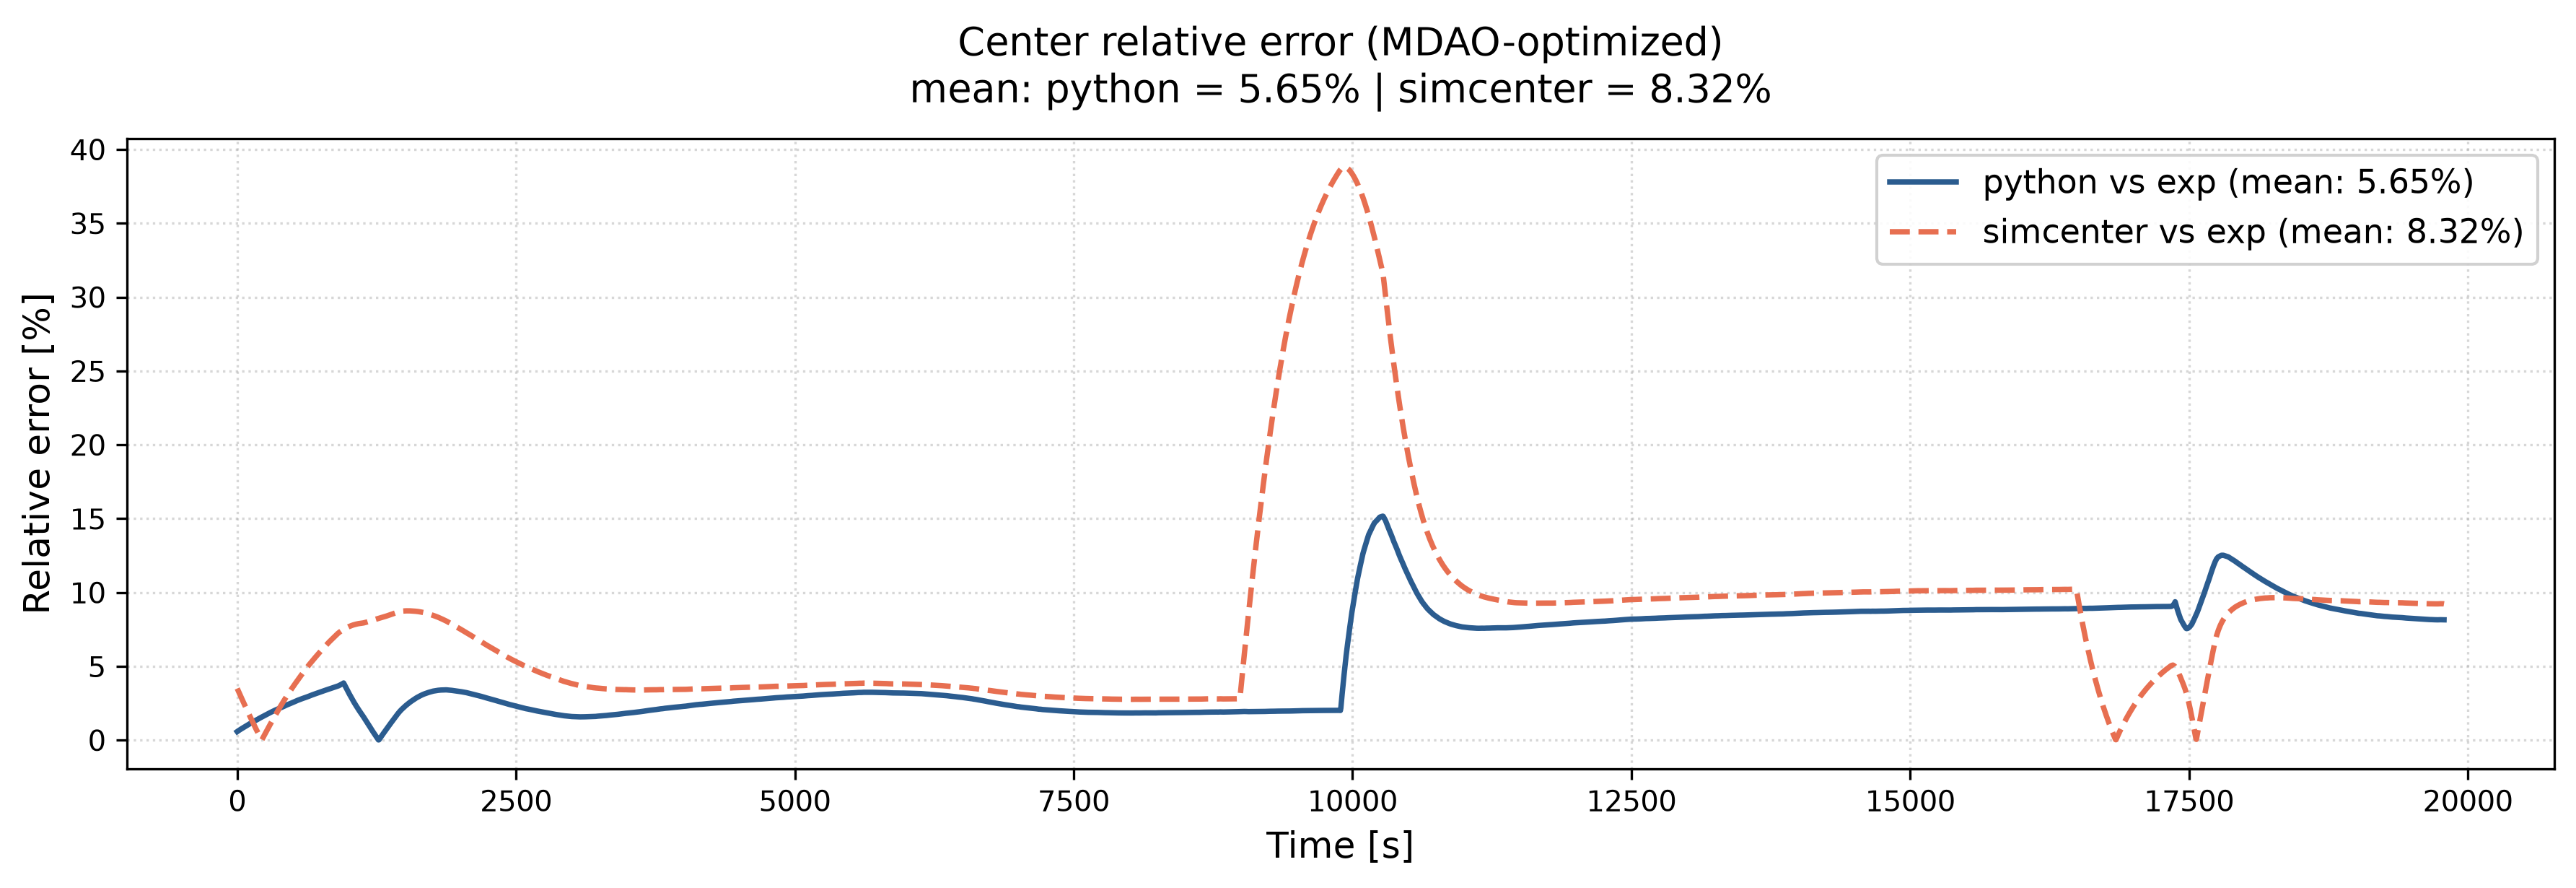

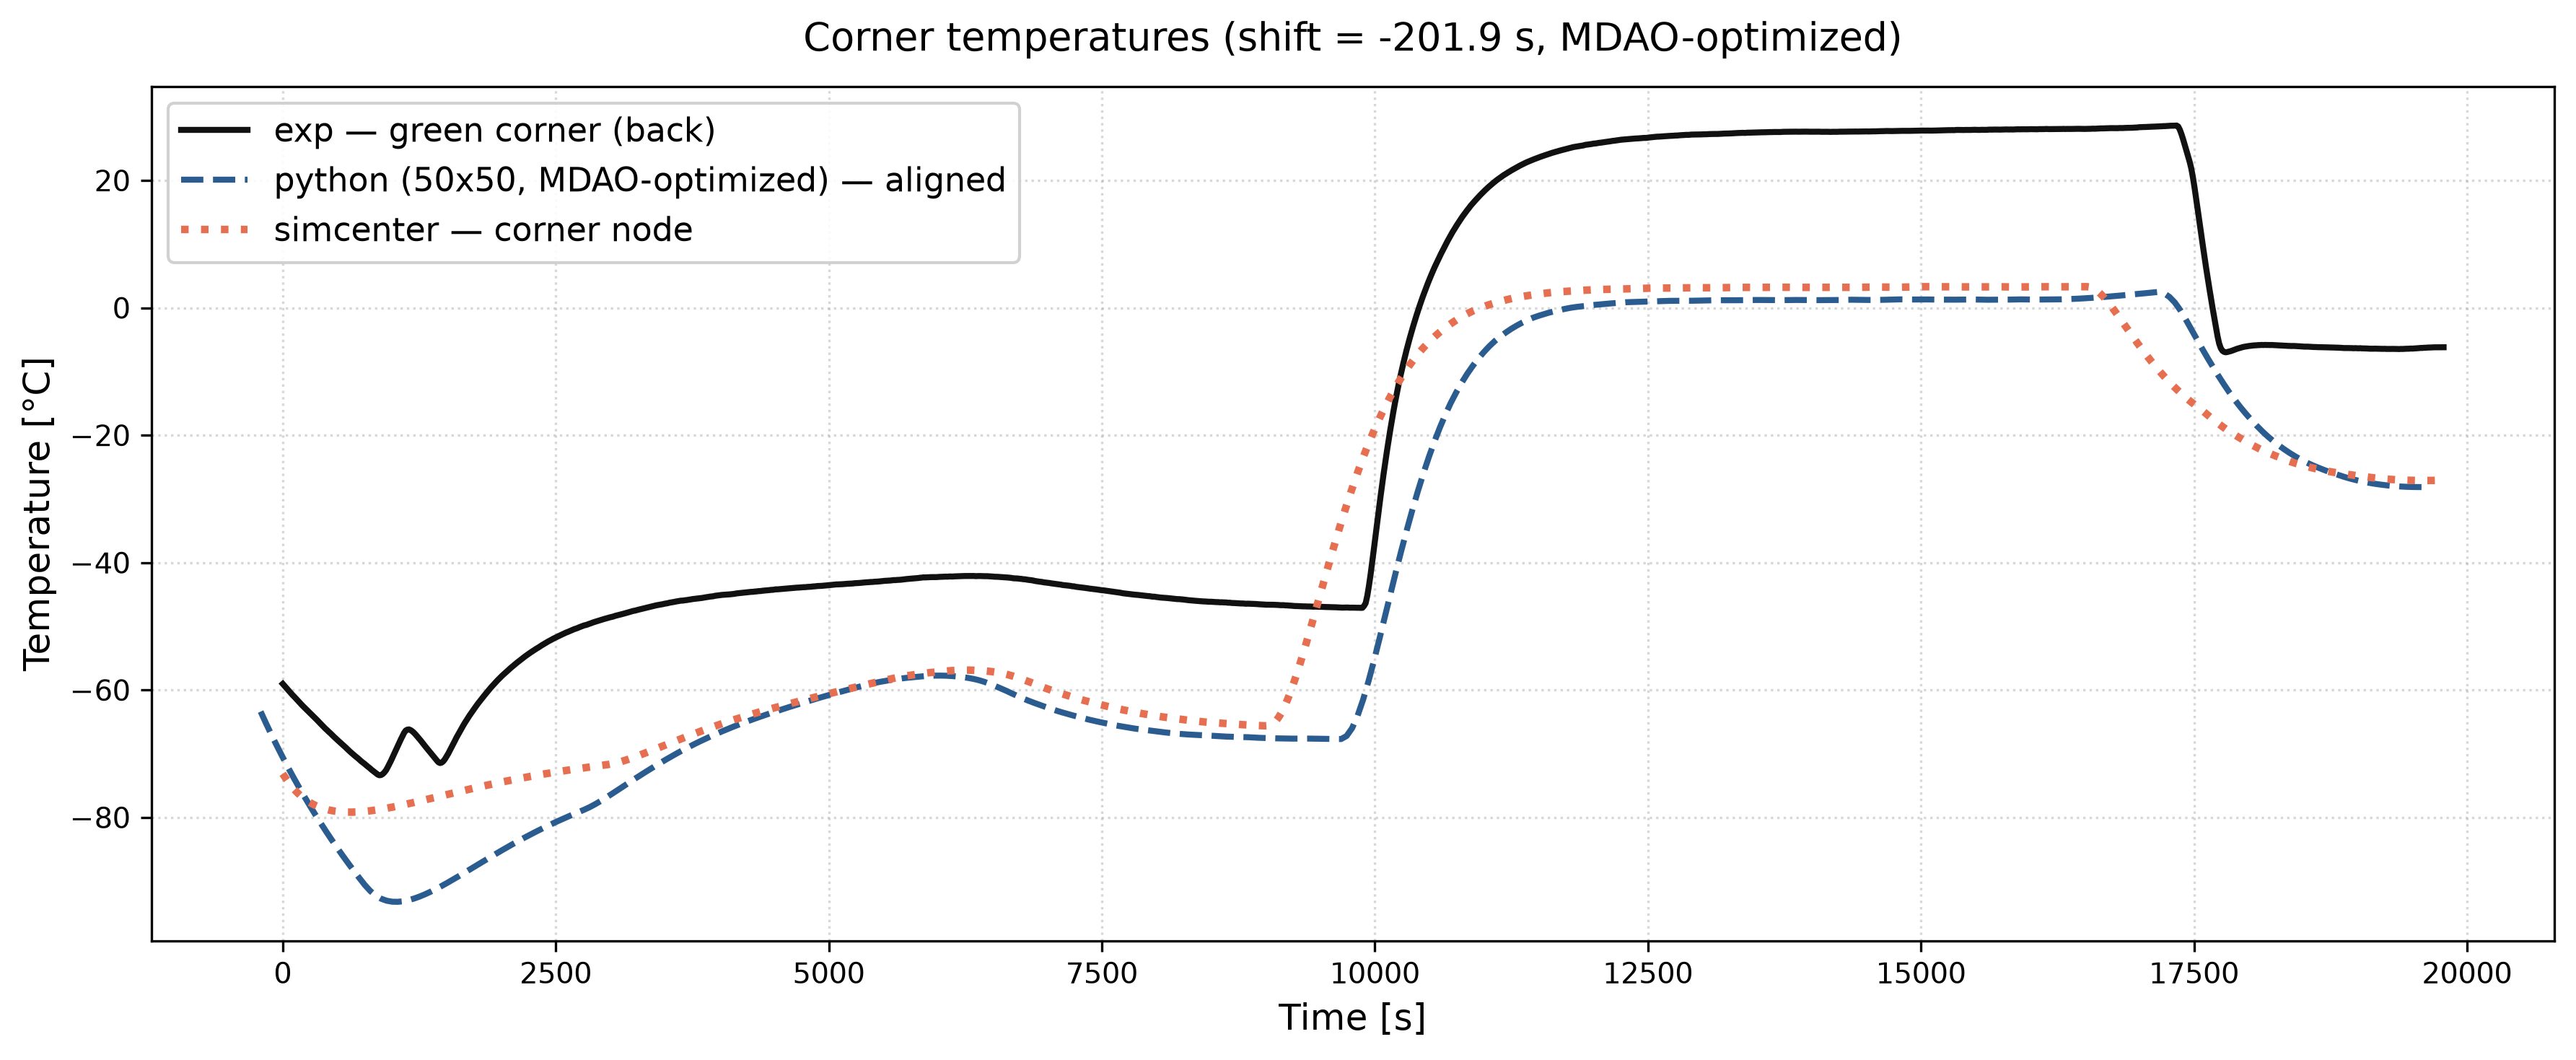

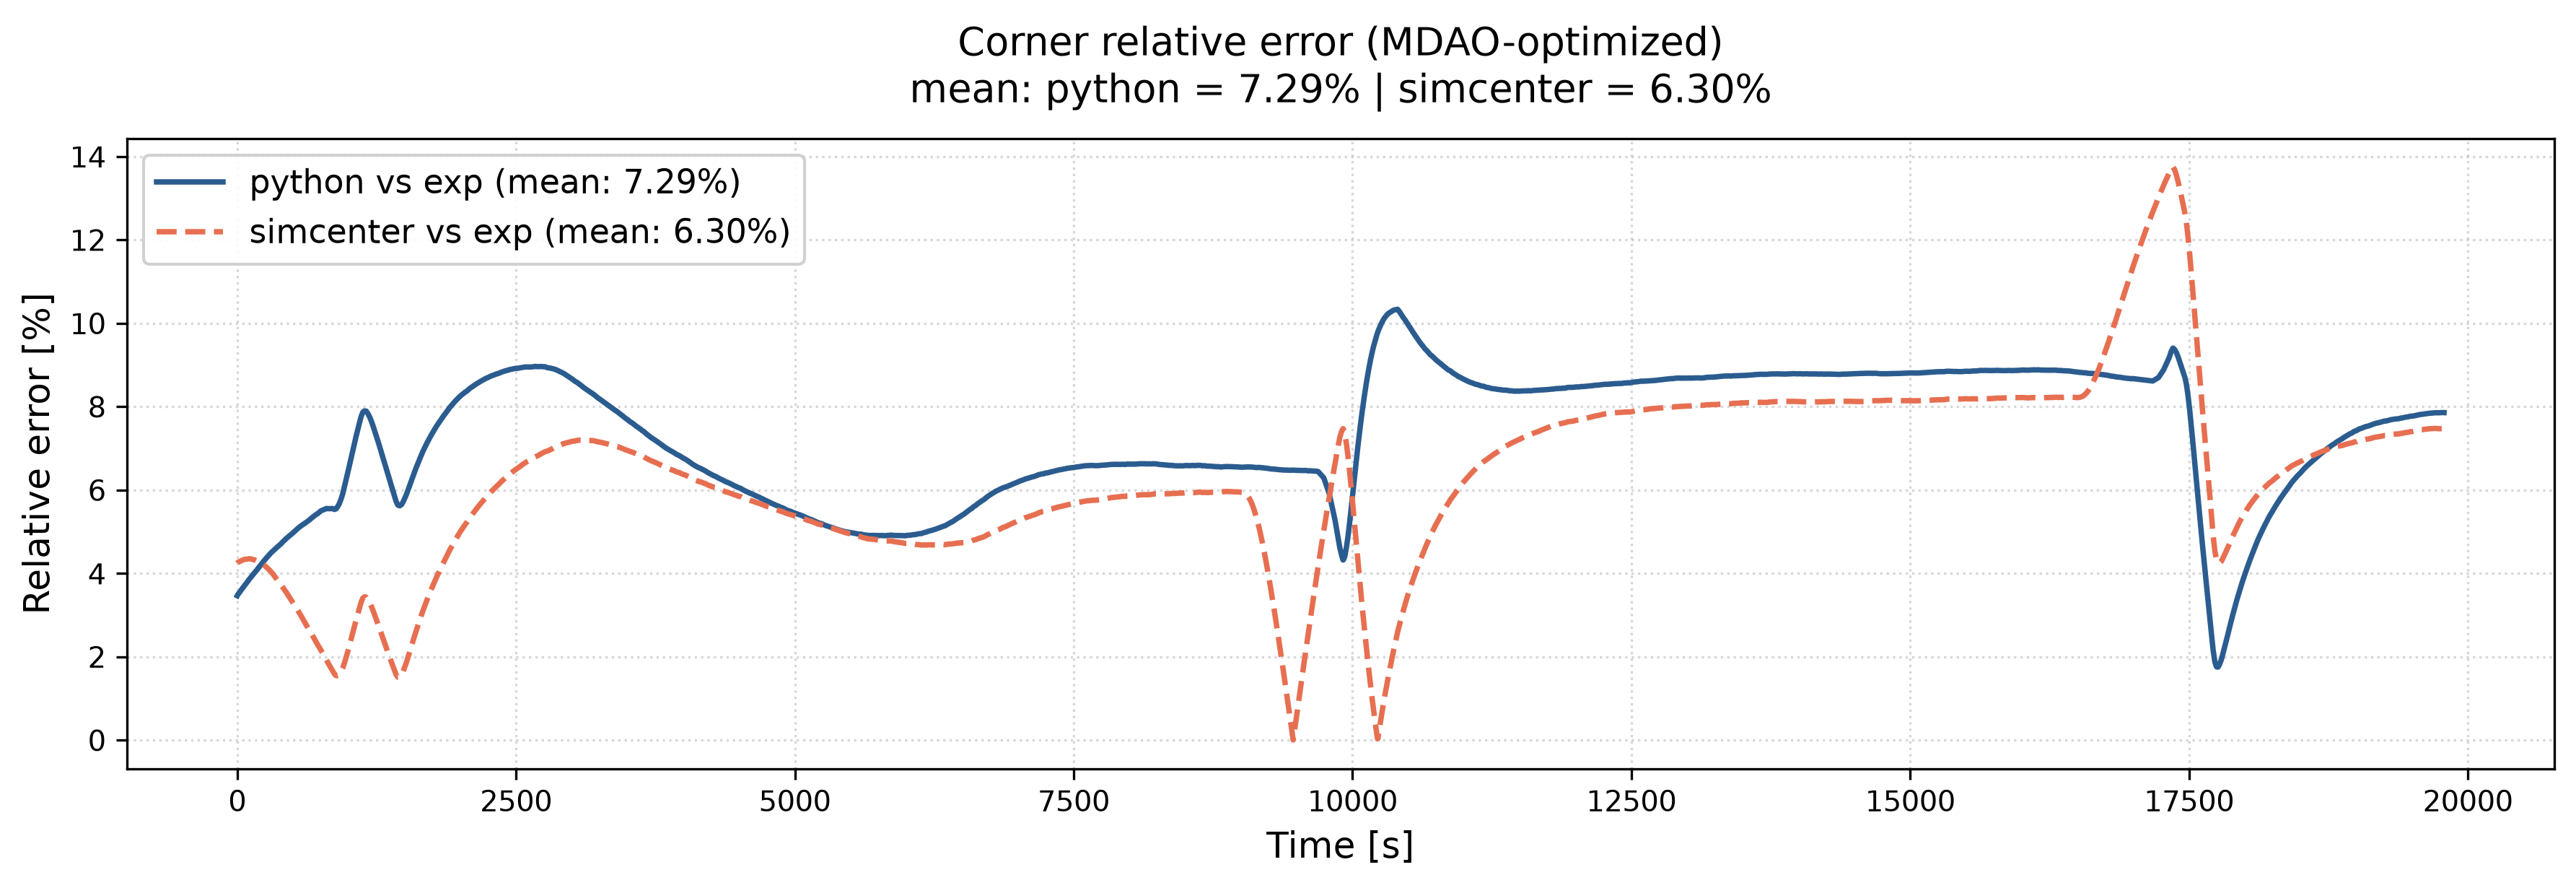

In [21]:
# ---------------------------------------------------------------------------
# inject the CasADi-optimized parameters into the implicit 50x50 solver
# ---------------------------------------------------------------------------
cp = cp_opt
k = k_opt
emissivity = eps_opt
efficiency = 0.6

# rebuild the 50x50 mesh (CasADi left it at 20x20)
Nx, Ny = 50, 50
N_nodes = Nx * Ny
dx, dy = L / Nx, W / Ny
A_node = dx * dy

x = np.linspace(dx/2, L - dx/2, Nx)
y = np.linspace(dy/2, W - dy/2, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

heater_mask = ((np.abs(X - L/2) <= heater_side/2) & (np.abs(Y - W/2) <= heater_side/2)).flatten()
num_heated_nodes = np.sum(heater_mask)

# recompute derived quantities that depend on the optimized params
C_node = rho * (dx * dy * e) * cp
Gx = k * e * (dy / dx)
Gy = k * e * (dx / dy)

# recompute T_shroud_eff_K on the full time_rad_sec grid (it was strided in the opti block)
T_top_K_full = df_filt["Shroud Top"].values + 273.15
T_bot_K_full = df_filt["Shroud Bottom"].values + 273.15
T_shroud_eff_K = (0.5 * (T_top_K_full**4) + 0.5 * (T_bot_K_full**4))**(1/4)

# dt=50 grid for the production run
dt = 50
time_total = min(time_pwr_sec[-1], time_rad_sec[-1])
Nt = int(time_total / dt)
time_array = np.linspace(0, time_total, Nt)

T_shroud_real = np.interp(time_array, time_rad_sec, T_shroud_eff_K)
P_step = np.array([get_step_power(t) for t in time_array])

T_vec = np.ones(N_nodes) * T_init_K
T_all_history = np.zeros((Nt, Nx, Ny))

print(f"Running implicit solver ({Nx}x{Ny}, dt = {dt}s, optimized params)...")
print(f"  cp = {cp:.2f} | k = {k:.4f} | emissivity = {emissivity:.4f}")

for step in range(Nt):
    T_env = T_shroud_real[step]

    P_eff = P_step[step] * efficiency
    P_per_node = (P_eff / num_heated_nodes) if num_heated_nodes > 0 else 0.0
    Q_heat = heater_mask * P_per_node

    h_rad_eq = 4.0 * emissivity * sigma * A_node * (T_vec ** 3)
    Q_rad_n = emissivity * sigma * A_node * (T_vec ** 4 - T_env ** 4)

    A = lil_matrix((N_nodes, N_nodes))
    B = np.zeros(N_nodes)

    for i in range(Nx):
        for j in range(Ny):
            p = get_index(i, j)
            diag_val = (C_node / dt) + h_rad_eq[p]

            if i > 0:
                A[p, get_index(i - 1, j)] = -Gx
                diag_val += Gx
            if i < Nx - 1:
                A[p, get_index(i + 1, j)] = -Gx
                diag_val += Gx
            if j > 0:
                A[p, get_index(i, j - 1)] = -Gy
                diag_val += Gy
            if j < Ny - 1:
                A[p, get_index(i, j + 1)] = -Gy
                diag_val += Gy

            A[p, p] = diag_val
            B[p] = (C_node / dt) * T_vec[p] + Q_heat[p] - Q_rad_n[p] + h_rad_eq[p] * T_vec[p]

    T_vec = spsolve(A.tocsr(), B)
    T_all_history[step, :, :] = T_vec.reshape((Nx, Ny)) - 273.15

sim_center_50 = T_all_history[:, Nx // 2, Ny // 2]
sim_corner_50 = T_all_history[:, 0, 0]

# ---------------------------------------------------------------------------
# temporal alignment + relative error calculations
# ---------------------------------------------------------------------------

t_exp = np.asarray(time_rad_sec, dtype=float).ravel()
t_sim_raw = np.asarray(time_array, dtype=float).ravel()

# --- center ---
exp_center = np.asarray(df_filt["Green Center"].values, dtype=float).ravel()
sim_center = np.asarray(sim_center_50, dtype=float).ravel()
t_sim_c = np.linspace(t_sim_raw[0], t_sim_raw[-1], len(sim_center)) if len(t_sim_raw) != len(sim_center) else t_sim_raw

t_common_c = np.linspace(0, min(t_exp[-1], t_sim_c[-1]), 5000)
exp_i_c = np.interp(t_common_c, t_exp, exp_center)
sim_i_c = np.interp(t_common_c, t_sim_c, sim_center)

shift_center = best_shift(exp_i_c, sim_i_c) * (t_common_c[1] - t_common_c[0])
t_sim_aligned_center = t_sim_c + shift_center

sim_center_interp = np.interp(t_common_c, t_sim_aligned_center, sim_center)
exp_center_interp = np.interp(t_common_c, t_exp, exp_center)
err_rel_center_py = 100 * np.abs(sim_center_interp - exp_center_interp) / (np.abs(exp_center_interp) + 273.15)

t_common_sc_c = np.linspace(0, min(t_exp[-1], t_central[-1]), 5000)
exp_sc_interp_c = np.interp(t_common_sc_c, t_exp, exp_center)
simcenter_interp_c = np.interp(t_common_sc_c, t_central, T_central)
err_rel_center_sc = 100 * np.abs(simcenter_interp_c - exp_sc_interp_c) / (np.abs(exp_sc_interp_c) + 273.15)

mean_c_py = np.mean(err_rel_center_py)
mean_c_sc = np.mean(err_rel_center_sc)

# --- corner ---
exp_corner = np.asarray(df_filt["Green Corner (back)"].values, dtype=float).ravel()
sim_corner = np.asarray(sim_corner_50, dtype=float).ravel()
t_sim_co = np.linspace(t_sim_raw[0], t_sim_raw[-1], len(sim_corner)) if len(t_sim_raw) != len(sim_corner) else t_sim_raw

t_common_co = np.linspace(0, min(t_exp[-1], t_sim_co[-1]), 5000)
exp_i_co = np.interp(t_common_co, t_exp, exp_corner)
sim_i_co = np.interp(t_common_co, t_sim_co, sim_corner)

shift_corner = best_shift(exp_i_co, sim_i_co) * (t_common_co[1] - t_common_co[0])
t_sim_aligned_corner = t_sim_co + shift_corner

sim_corner_interp = np.interp(t_common_co, t_sim_aligned_corner, sim_corner)
exp_corner_interp = np.interp(t_common_co, t_exp, exp_corner)
err_rel_corner_py = 100 * np.abs(sim_corner_interp - exp_corner_interp) / (np.abs(exp_corner_interp) + 273.15)

t_common_sc_co = np.linspace(0, min(t_exp[-1], t_corner[-1]), 5000)
exp_sc_interp_co = np.interp(t_common_sc_co, t_exp, exp_corner)
simcenter_interp_co = np.interp(t_common_sc_co, t_corner, T_corner)
err_rel_corner_sc = 100 * np.abs(simcenter_interp_co - exp_sc_interp_co) / (np.abs(exp_sc_interp_co) + 273.15)

mean_co_py = np.mean(err_rel_corner_py)
mean_co_sc = np.mean(err_rel_corner_sc)

print(f"Shift center: {shift_center:.2f} s | Shift corner: {shift_corner:.2f} s")

# ---------------------------------------------------------------------------
# plots — temperatures + relative errors
# ---------------------------------------------------------------------------

# center temperatures
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(t_exp, exp_center, label="exp — green center", color='#111111', linewidth=2.0)
plt.plot(t_sim_aligned_center, sim_center, label="python (50x50, MDAO-optimized) — aligned", color='#2b5c8f', linestyle='--', linewidth=2.0)
plt.plot(t_central, T_central, label="simcenter — central node", color='#e76f51', linestyle=':', linewidth=2.5)
plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Temperature [°C]", fontsize=12)
plt.title(f"Center temperatures (shift = {shift_center:+.1f} s, MDAO-optimized)", fontsize=13, pad=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

# center relative error
plt.figure(figsize=(12, 4.2), dpi=300)
plt.plot(t_common_c, err_rel_center_py, label=f"python vs exp (mean: {mean_c_py:.2f}%)", color='#2b5c8f', linewidth=1.8)
plt.plot(t_common_sc_c, err_rel_center_sc, label=f"simcenter vs exp (mean: {mean_c_sc:.2f}%)", color='#e76f51', linestyle='--', linewidth=1.8)
plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Relative error [%]", fontsize=12)
plt.title(f"Center relative error (MDAO-optimized)\n"
          f"mean: python = {mean_c_py:.2f}% | simcenter = {mean_c_sc:.2f}%", fontsize=13, pad=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

# corner temperatures
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(t_exp, exp_corner, label="exp — green corner (back)", color='#111111', linewidth=2.0)
plt.plot(t_sim_aligned_corner, sim_corner, label="python (50x50, MDAO-optimized) — aligned", color='#2b5c8f', linestyle='--', linewidth=2.0)
plt.plot(t_corner, T_corner, label="simcenter — corner node", color='#e76f51', linestyle=':', linewidth=2.5)
plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Temperature [°C]", fontsize=12)
plt.title(f"Corner temperatures (shift = {shift_corner:+.1f} s, MDAO-optimized)", fontsize=13, pad=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

# corner relative error
plt.figure(figsize=(12, 4.2), dpi=300)
plt.plot(t_common_co, err_rel_corner_py, label=f"python vs exp (mean: {mean_co_py:.2f}%)", color='#2b5c8f', linewidth=1.8)
plt.plot(t_common_sc_co, err_rel_corner_sc, label=f"simcenter vs exp (mean: {mean_co_sc:.2f}%)", color='#e76f51', linestyle='--', linewidth=1.8)
plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Relative error [%]", fontsize=12)
plt.title(f"Corner relative error (MDAO-optimized)\n"
          f"mean: python = {mean_co_py:.2f}% | simcenter = {mean_co_sc:.2f}%", fontsize=13, pad=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()